In [1]:
# ================================================================
# SUPPLY CHAIN PROFITABILITY ANALYSIS
# FMCG Industry - 2023-2025
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os

# Creave file to store graphs
if not os.path.exists("report graphs"):
    os.makedirs("report graphs")
    print("📁 Created folder: report graphs")


# Set visualization style - FIXED for compatibility
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        plt.style.use('default')  # Fallback to default

sns.set_palette("Set2")
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100

In [2]:
# ================================================================
# STEP 1: DATA LOADING & VALIDATION
# ================================================================
print("=" * 70)
print("FMCG Profitability Analysis (2023-2025)")
print("=" * 70)

df = pd.read_csv("fmcg_sales_marketing_profitability_2023_2025.csv")

# Convert date
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month

print("STEP 1: DATA LOADING & VALIDATION")
print("-" * 50)

# Data snapshot
print("\nDataset snapshot:")
print(df.head())

# Data quality
print(f"\nShape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Period: {df['Order_Date'].min().date()} ~ {df['Order_Date'].max().date()}")
print(f"Missing values: {df.isnull().sum().sum()} (clean)")

# Dataset profile
print("\nDataset Profile:")
print(f"  Regions: {df['Region'].nunique()} -> {', '.join(sorted(df['Region'].unique()))}")
print(f"  Countries: {df['Country'].nunique()} -> {', '.join(sorted(df['Country'].unique()))}")
print(f"  Cities: {df['City'].nunique()}")
print(f"  Categories: {df['Product_Category'].nunique()} -> {', '.join(sorted(df['Product_Category'].unique()))}")
print(f"  Channels: {df['Sales_Channel'].nunique()} -> {', '.join(sorted(df['Sales_Channel'].unique()))}")
print(f"  Customer Types: {df['Customer_Type'].nunique()} -> {', '.join(sorted(df['Customer_Type'].unique()))}")
print(f"  Total Orders: {df['Order_ID'].nunique():,}")
print(f"  Unique Products: {df['Product_Name'].nunique()}")

FMCG Profitability Analysis (2023-2025)


STEP 1: DATA LOADING & VALIDATION
--------------------------------------------------

Dataset snapshot:
           Order_ID Order_Date  Year Quarter  Month Month_Name         Region  \
0  FMCG-2025-000001 2025-09-26  2025      Q3      9  September        Oceania   
1  FMCG-2024-000002 2024-10-09  2024      Q4     10    October           Asia   
2  FMCG-2024-000003 2024-07-06  2024      Q3      7       July  North America   
3  FMCG-2024-000004 2024-05-25  2024      Q2      5        May         Europe   
4  FMCG-2023-000005 2023-08-10  2023      Q3      8     August         Europe   

     Country         City   Sales_Person  ... Units_Sold Unit_Price_USD  \
0  Australia        Perth     Ethan Cole  ...         73           8.47   
1      India       Mumbai     Meera Nair  ...         99           2.89   
2        USA  Los Angeles    Nina Booker  ...        361           5.96   
3     France        Paris    Oliver Kent  ...        603           3.80   
4     France         Lyon  Lucas B

In [3]:
# ================================================================
# STEP 2: PERFORMANCE DASHBOARD
# ================================================================

print("\nSTEP 2: PERFORMANCE DASHBOARD")
print("-" * 50)

# Volume metrics
total_revenue = df['Net_Revenue_USD'].sum()
total_profit = df['Profit_USD'].sum()
total_units = df['Units_Sold'].sum()
total_orders = df['Order_ID'].nunique()
years = df['Year'].nunique()

print(f"\nRevenue:     ${total_revenue:,.0f} total  |  ${total_revenue/years:,.0f}/yr avg.")
print(f"Profit:      ${total_profit:,.0f} total  |  ${total_profit/years:,.0f}/yr avg.")
print(f"Margin:      {df['Profit_Margin_Pct'].mean():.1f}% avg.")
print(f"Units Sold:  {total_units:,.0f}  |  Orders: {total_orders:,}")
print(f"Avg Order:   ${total_revenue/total_orders:,.0f}  |  Avg Units/Order: {total_units/total_orders:.1f}")

# Cost ratios
cogs_rate = df['COGS_USD'].sum() / total_revenue * 100
logistics_rate = df['Logistics_Cost_USD'].sum() / total_revenue * 100
marketing_rate = df['Marketing_Spend_USD'].sum() / total_revenue * 100
discount_rate = (df['Gross_Sales_USD'] - df['Net_Revenue_USD']).sum() / df['Gross_Sales_USD'].sum() * 100

print(f"\nCost Structure (% of Revenue):")
print(f"  COGS:       {cogs_rate:.1f}%")
print(f"  Logistics:  {logistics_rate:.1f}%")
print(f"  Marketing:  {marketing_rate:.1f}%")
print(f"  Discount:   {discount_rate:.1f}% (of Gross Sales)")
print(f"  Margin:     {df['Profit_Margin_Pct'].mean():.1f}%")

print(f"\n📌 COGS + Logistics + Marketing = {cogs_rate + logistics_rate + marketing_rate:.1f}% of revenue")
print(f"   Remaining {100 - (cogs_rate + logistics_rate + marketing_rate):.1f}% = Profit + other operating costs")

print("\nMetric Definitions:")
print("   Margin %     = Profit / Revenue")
print("   COGS %       = COGS / Revenue")
print("   Logistics %  = Logistics Cost / Revenue")
print("   Marketing %  = Marketing Spend / Revenue")
print("   Discount %   = Discount / Gross Sales")
print("   All % are 3-year averages.")


STEP 2: PERFORMANCE DASHBOARD
--------------------------------------------------

Revenue:     $14,449,920 total  |  $4,816,640/yr avg.
Profit:      $3,308,965 total  |  $1,102,988/yr avg.
Margin:      19.9% avg.
Units Sold:  3,883,474  |  Orders: 18,240
Avg Order:   $792  |  Avg Units/Order: 212.9

Cost Structure (% of Revenue):
  COGS:       59.5%
  Logistics:  6.8%
  Marketing:  10.8%
  Discount:   15.4% (of Gross Sales)
  Margin:     19.9%

📌 COGS + Logistics + Marketing = 77.1% of revenue
   Remaining 22.9% = Profit + other operating costs

Metric Definitions:
   Margin %     = Profit / Revenue
   COGS %       = COGS / Revenue
   Logistics %  = Logistics Cost / Revenue
   Marketing %  = Marketing Spend / Revenue
   Discount %   = Discount / Gross Sales
   All % are 3-year averages.


In [4]:
# ================================================================
# STEP 3: REGIONAL PERFORMANCE ANALYSIS
# ================================================================

print("\nSTEP 3: REGIONAL PERFORMANCE ANALYSIS")
print("-" * 50)

# --- 1. Regional Performance Table ---
region_analysis = df.groupby('Region').agg({
    'Net_Revenue_USD': 'sum',
    'Profit_USD': 'sum',
    'Units_Sold': 'sum',
    'Logistics_Cost_USD': 'sum',
    'COGS_USD': 'sum'
}).round(2)

region_analysis['Margin_Pct'] = (region_analysis['Profit_USD'] / region_analysis['Net_Revenue_USD']) * 100
region_analysis['Logistics_Rate'] = (region_analysis['Logistics_Cost_USD'] / region_analysis['Net_Revenue_USD']) * 100
region_analysis['COGS_Rate'] = (region_analysis['COGS_USD'] / region_analysis['Net_Revenue_USD']) * 100
region_analysis['Profit_per_Unit'] = region_analysis['Profit_USD'] / region_analysis['Units_Sold']

display_cols = ['Net_Revenue_USD', 'Margin_Pct', 'Logistics_Rate', 'COGS_Rate', 'Profit_per_Unit', 'Logistics_Cost_USD']
region_display = region_analysis[display_cols].round(2)

print("\nRegional Performance:")
print("-" * 95)
print(f"{'Region':<16} {'Revenue':>14} {'Margin':>9} {'Logistics':>9} {'COGS':>9} {'Profit/Unit':>11} {'Logistics Cost':>14}")
print("-" * 95)

for region in region_display.index:
    print(f"{region:<16} ${region_display.loc[region, 'Net_Revenue_USD']:>13,.0f} "
          f"{region_display.loc[region, 'Margin_Pct']:>8.2f} "
          f"{region_display.loc[region, 'Logistics_Rate']:>8.2f} "
          f"{region_display.loc[region, 'COGS_Rate']:>8.2f} "
          f"{region_display.loc[region, 'Profit_per_Unit']:>10.2f} "
          f"${region_display.loc[region, 'Logistics_Cost_USD']:>13,.0f}")

print("-" * 95)
print(f"{'AVERAGE':<16} ${region_display['Net_Revenue_USD'].mean():>13,.0f} "
      f"{region_display['Margin_Pct'].mean():>8.2f} "
      f"{region_display['Logistics_Rate'].mean():>8.2f} "
      f"{region_display['COGS_Rate'].mean():>8.2f} "
      f"{region_display['Profit_per_Unit'].mean():>10.2f} "
      f"${region_display['Logistics_Cost_USD'].mean():>13,.0f}")
print("-" * 95)

# --- 2. Logistics Efficiency Breakdown ---
logistics_drivers = df.groupby('Region').agg({
    'Logistics_Cost_USD': 'sum',
    'Units_Sold': 'sum',
    'Net_Revenue_USD': 'sum',
    'Order_ID': 'count'
}).assign(
    Logistics_per_Unit=lambda x: x['Logistics_Cost_USD'] / x['Units_Sold'],
    Logistics_per_Order=lambda x: x['Logistics_Cost_USD'] / x['Order_ID'],
    Units_per_Order=lambda x: x['Units_Sold'] / x['Order_ID']
)

print("\nLogistics Efficiency:")
print(logistics_drivers.round(2).to_string())

# --- 3. Key Insights ---
print("\nKey Insights:")
best_region = region_analysis.nlargest(1, 'Margin_Pct').index[0]
worst_region = region_analysis.nsmallest(1, 'Margin_Pct').index[0]
best_log_region = logistics_drivers.nsmallest(1, 'Logistics_per_Unit').index[0]
worst_log_region = logistics_drivers.nlargest(1, 'Logistics_per_Unit').index[0]
gap_pct = ((logistics_drivers.loc[worst_log_region, 'Logistics_per_Unit'] / logistics_drivers.loc[best_log_region, 'Logistics_per_Unit']) - 1) * 100

print(f"  • Best:  {best_region} ({region_analysis.loc[best_region, 'Margin_Pct']:.1f}% margin, {region_analysis.loc[best_region, 'Logistics_Rate']:.1f}% logistics)")
print(f"  • Worst: {worst_region} ({region_analysis.loc[worst_region, 'Margin_Pct']:.1f}% margin, {region_analysis.loc[worst_region, 'Logistics_Rate']:.1f}% logistics)")
print(f"  • Logistics cost per unit: {worst_log_region} (${logistics_drivers.loc[worst_log_region, 'Logistics_per_Unit']:.2f}) vs {best_log_region} (${logistics_drivers.loc[best_log_region, 'Logistics_per_Unit']:.2f}) → {gap_pct:.0f}% gap")
print(f"  • Regional avg. margin: {region_analysis['Margin_Pct'].mean():.2f}%")
print(f"  • Regional avg. logistics: {region_analysis['Logistics_Rate'].mean():.2f}%")
print(f"  • Units per order: ~{logistics_drivers['Units_per_Order'].mean():.0f} across all regions → similar order structure")


STEP 3: REGIONAL PERFORMANCE ANALYSIS
--------------------------------------------------

Regional Performance:
-----------------------------------------------------------------------------------------------
Region                  Revenue    Margin Logistics      COGS Profit/Unit Logistics Cost
-----------------------------------------------------------------------------------------------
Asia             $    2,946,505    22.75     6.83    59.64       0.71 $      201,231
Europe           $    4,811,497    23.60     6.50    59.02       0.97 $      312,738
North America    $    3,337,777    23.37     6.50    59.09       0.89 $      216,988
Oceania          $    1,625,625    19.61     8.01    61.65       0.83 $      130,205
South America    $    1,728,515    23.39     7.20    59.02       0.79 $      124,377
-----------------------------------------------------------------------------------------------
AVERAGE          $    2,889,984    22.54     7.01    59.68       0.84 $      197,108


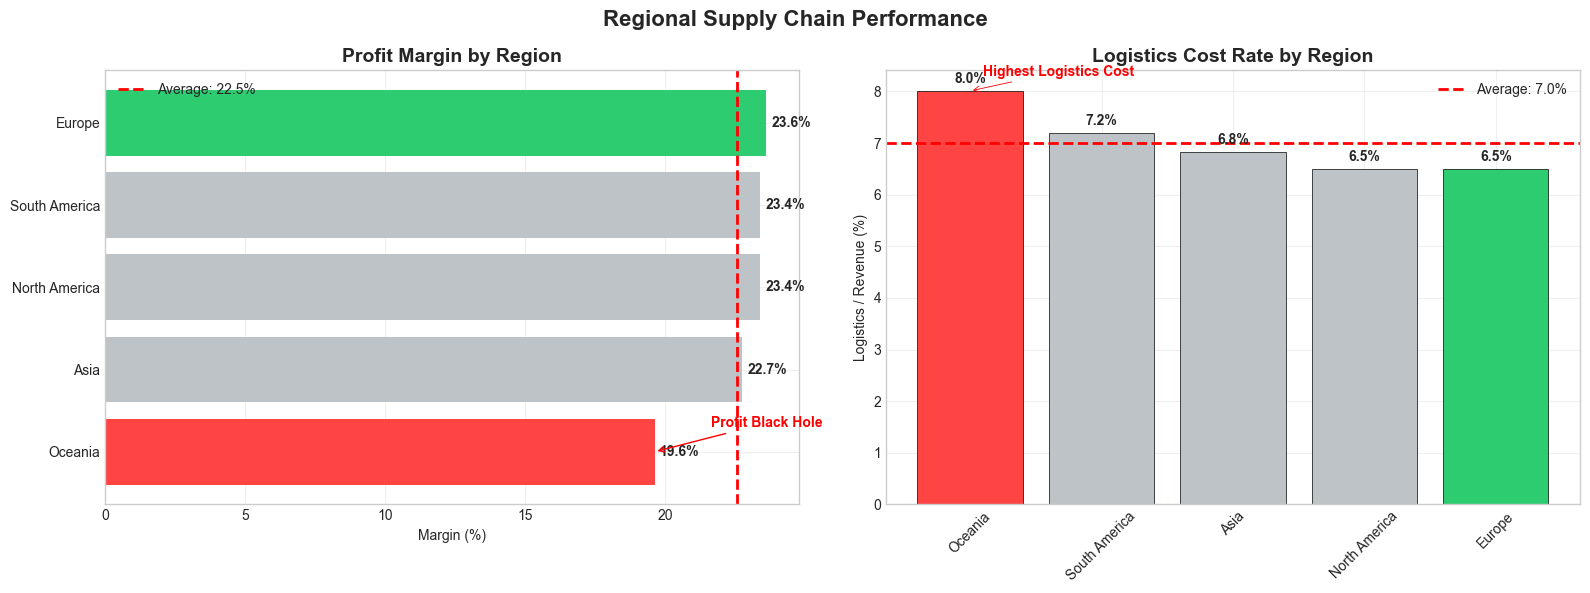

In [5]:
# ================================================================
# STEP 3: REGIONAL VISUALIZATION
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Regional Supply Chain Performance', fontsize=16, fontweight='bold')

# ================================================================
# CHART 1: Profit Margin by Region (sorted worst to best)

# Sort by margin (ascending = worst first)
region_sorted = region_analysis.sort_values('Margin_Pct', ascending=True)

# Color logic: Red for worst, Green for best, Gray for others
colors_margin = []
for i, region in enumerate(region_sorted.index):
    if i == 0:  # Worst
        colors_margin.append('#FF4444')  # Red
    elif i == len(region_sorted) - 1:  # Best
        colors_margin.append('#2ECC71')  # Green
    else:
        colors_margin.append('#BDC3C7')  # Gray

bars1 = axes[0].barh(region_sorted.index, region_sorted['Margin_Pct'], color=colors_margin)
axes[0].axvline(x=region_analysis['Margin_Pct'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f'Average: {region_analysis["Margin_Pct"].mean():.1f}%')

# Add value labels on bars
for bar, val in zip(bars1, region_sorted['Margin_Pct']):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

# Add annotation for problem region (Oceania)
if 'Oceania' in region_sorted.index:
    axes[0].annotate('Profit Black Hole', 
                    xy=(region_sorted.loc['Oceania', 'Margin_Pct'], 
                        region_sorted.index.get_loc('Oceania')),
                    xytext=(region_sorted.loc['Oceania', 'Margin_Pct'] + 2, 
                            region_sorted.index.get_loc('Oceania') + 0.3),
                    fontsize=10, color='red', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='red', lw=1))

axes[0].set_title('Profit Margin by Region', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Margin (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ================================================================
# CHART 2: Logistics Cost Rate by Region (sorted highest to lowest)

# Sort by logistics rate (descending = worst first)
region_logistics = region_analysis.sort_values('Logistics_Rate', ascending=False)

# Color logic: Red for highest logistics, Green for lowest, Gray for others
colors_log = []
for i, region in enumerate(region_logistics.index):
    if i == 0:  # Highest logistics cost
        colors_log.append('#FF4444')  # Red
    elif i == len(region_logistics) - 1:  # Lowest logistics cost
        colors_log.append('#2ECC71')  # Green
    else:
        colors_log.append('#BDC3C7')  # Gray

bars2 = axes[1].bar(region_logistics.index, region_logistics['Logistics_Rate'], 
                    color=colors_log, edgecolor='black', linewidth=0.5)
axes[1].axhline(y=region_analysis['Logistics_Rate'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f'Average: {region_analysis["Logistics_Rate"].mean():.1f}%')

# Add value labels on bars
for bar, val in zip(bars2, region_logistics['Logistics_Rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.1, 
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add annotation for problem region (Oceania)
if 'Oceania' in region_logistics.index:
    axes[1].annotate('Highest Logistics Cost', 
                    xy=(region_logistics.index.get_loc('Oceania'), 
                        region_logistics.loc['Oceania', 'Logistics_Rate']),
                    xytext=(region_logistics.index.get_loc('Oceania') + 0.1, 
                            region_logistics.loc['Oceania', 'Logistics_Rate'] + 0.3),
                    fontsize=10, color='red', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='red', lw=0.6))

axes[1].set_title('Logistics Cost Rate by Region', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Logistics / Revenue (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("report graphs/03_Regional_Analysis.png", dpi=120, bbox_inches='tight')
plt.show()

## STEP 3: REGIONAL ANALYSIS - INSIGHTS & RECOMMENDATIONS

### Key Insights (see chart: Regional Analysis)

- **Performance gap:** Europe (23.6% margin, 6.5% logistics) vs Oceania (19.6% margin, 8.0% logistics). Oceania margin is 4.0pp below Europe, 2.9pp below regional average.

- **Cost structure gap:** Oceania logistics rate is 1.0pp above average (8.0% vs 7.0%); COGS rate is 2.0pp above average (61.7% vs 59.7%). Unit logistics cost is $0.34, 62% higher than Asia ($0.21).

- **Order structure:** All regions have similar units per order (~213). Order size is similar across regions.

- **Benchmark:** Asia has the lowest unit logistics cost ($0.21). Europe has the lowest logistics rate (6.5%) and highest margin (23.6%).

### Recommendations

1. **Investigate Oceania logistics rate**
   - Current: 8.0% vs regional avg 7.0%
   - If rate aligns with avg → potential savings: $16,296/year
   - Formula: $130,205 - ($1,625,625 × 7.0%)

2. **Investigate unit logistics cost**
   - Current: $0.34 vs Asia $0.21
   - If Oceania reaches Asia level → potential savings: $49,209/year
   - This is 3× larger than rate optimization

3. **Investigate Oceania COGS**
   - Current: 61.7% vs regional avg 59.7%
   - If COGS aligns with avg → potential savings: $31,989/year

4. **Study best practices**
   - Asia: delivery network efficiency (unit cost $0.21)
   - Europe: distribution contracts (logistics rate 6.5%, margin 23.6%)

### Summary

- Oceania shows the lowest margin (19.6%) and highest logistics cost (8.0%)
- Logistics rate optimization: $16,296/year
- Unit cost optimization (to Asia level): $49,209/year
- Focus: reduce cost-per-unit, not just rate percentage

##### 洞察2（区域分析）：
###### 区域分析发现：欧洲表现最好，大洋洲是利润黑洞。欧洲利润率最高（23.6%），物流最低（6.5%）。大洋洲利润率最低（19.6%），物流最高（8.0%）。

###### 深入看，大洋洲单位物流成本$0.34，比亚洲贵62%。但每单件数大家都在210件左右，所以不是订单量的问题，是地理和基础设施的问题。

###### 建议有两个层面：
###### 1.物流费率若能从8.0%降到7.0%，每年省$1.6万
###### 2.单位物流成本若能降到亚洲水平，每年省$4.9万——效果是费率的3倍

###### 总结：向亚洲学配送效率，向欧洲学分销合同。

In [6]:
# ================================================================
# STEP 4: PRODUCT CATEGORY ANALYSIS
# ================================================================

print("\nSTEP 4: PRODUCT CATEGORY ANALYSIS")
print("-" * 50)

# --- 1. Category Performance Table ---
category_analysis = df.groupby('Product_Category').agg({
    'Net_Revenue_USD': 'sum',
    'Profit_USD': 'sum',
    'Profit_Margin_Pct': 'mean',
    'Units_Sold': 'sum',
    'Logistics_Cost_USD': 'sum',
    'Discount_Pct': 'mean',
    'COGS_USD': 'sum'
}).round(2)

category_analysis['Margin_Pct'] = (category_analysis['Profit_USD'] / category_analysis['Net_Revenue_USD']) * 100
category_analysis['COGS_Rate'] = (category_analysis['COGS_USD'] / category_analysis['Net_Revenue_USD']) * 100
category_analysis['Logistics_Rate'] = (category_analysis['Logistics_Cost_USD'] / category_analysis['Net_Revenue_USD']) * 100
category_analysis['Profit_per_Unit'] = category_analysis['Profit_USD'] / category_analysis['Units_Sold']

display_cols = ['Net_Revenue_USD', 'Margin_Pct', 'COGS_Rate', 'Logistics_Rate', 'Discount_Pct', 'Profit_per_Unit']
category_display = category_analysis[display_cols].round(2)

print("\nCategory Performance:")
print("-" * 100)
print(f"{'Category':<20} {'Revenue':>14} {'Margin':>9} {'COGS':>9} {'Logistics':>9} {'Discount':>9} {'Profit/Unit':>11}")
print("-" * 100)

for cat in category_display.index:
    print(f"{cat:<20} ${category_display.loc[cat, 'Net_Revenue_USD']:>13,.0f} "
          f"{category_display.loc[cat, 'Margin_Pct']:>8.2f} "
          f"{category_display.loc[cat, 'COGS_Rate']:>8.2f} "
          f"{category_display.loc[cat, 'Logistics_Rate']:>8.2f} "
          f"{category_display.loc[cat, 'Discount_Pct']:>8.2f} "
          f"{category_display.loc[cat, 'Profit_per_Unit']:>10.2f}")

print("-" * 100)
print(f"{'AVERAGE':<20} ${category_display['Net_Revenue_USD'].mean():>13,.0f} "
      f"{category_display['Margin_Pct'].mean():>8.2f} "
      f"{category_display['COGS_Rate'].mean():>8.2f} "
      f"{category_display['Logistics_Rate'].mean():>8.2f} "
      f"{category_display['Discount_Pct'].mean():>8.2f} "
      f"{category_display['Profit_per_Unit'].mean():>10.2f}")
print("-" * 100)

# --- 2. Pareto Analysis ---
product_revenue = df.groupby('Product_Name')['Net_Revenue_USD'].sum().sort_values(ascending=False)
total_revenue = product_revenue.sum()
cumsum_pct = product_revenue.cumsum() / total_revenue * 100

total_products = len(product_revenue)
top_80_count = (cumsum_pct <= 80).sum()

print("\nPareto Analysis:")
print(f"  Total products: {total_products}")
print(f"  Top {top_80_count} products generate 80% of revenue ({top_80_count/total_products*100:.0f}% of all products)")
print(f"  Remaining {total_products - top_80_count} products generate 20% of revenue")

# --- 3. Key Insights ---
avg_cogs = category_analysis['COGS_Rate'].mean()
avg_margin = category_analysis['Margin_Pct'].mean()
best_cat = category_analysis.nlargest(1, 'Margin_Pct').index[0]
worst_cat = category_analysis.nsmallest(1, 'Margin_Pct').index[0]

print("\nKey Insights:")
print(f"  • Best:  {best_cat} ({category_analysis.loc[best_cat, 'Margin_Pct']:.1f}% margin, {category_analysis.loc[best_cat, 'COGS_Rate']:.1f}% COGS)")
print(f"  • Worst: {worst_cat} ({category_analysis.loc[worst_cat, 'Margin_Pct']:.1f}% margin, {category_analysis.loc[worst_cat, 'COGS_Rate']:.1f}% COGS)")
print(f"  • Category avg. COGS: {avg_cogs:.1f}%")
print(f"  • Category avg. margin: {avg_margin:.1f}%")
print(f"  • {worst_cat} COGS: {category_analysis.loc[worst_cat, 'COGS_Rate']:.1f}% vs avg {avg_cogs:.1f}% (+{category_analysis.loc[worst_cat, 'COGS_Rate'] - avg_cogs:.1f}pp)")

# --- 4. Opportunity Calculation ---
worst_revenue = category_analysis.loc[worst_cat, 'Net_Revenue_USD']
current_cogs_cost = worst_revenue * (category_analysis.loc[worst_cat, 'COGS_Rate'] / 100)
target_cogs_cost = worst_revenue * (avg_cogs / 100)
cogs_savings = current_cogs_cost - target_cogs_cost

print(f"\nOpportunity:")
print(f"  If {worst_cat} COGS aligns with category avg. ({avg_cogs:.1f}%):")
print(f"    Current COGS: ${current_cogs_cost:,.0f}")
print(f"    Target COGS:  ${target_cogs_cost:,.0f}")
print(f"    Potential savings: ${cogs_savings:,.0f}/year")
print(f"    → {cogs_savings / category_analysis['Net_Revenue_USD'].sum() * 100:.1f}% of total company revenue")


STEP 4: PRODUCT CATEGORY ANALYSIS
--------------------------------------------------

Category Performance:
----------------------------------------------------------------------------------------------------
Category                    Revenue    Margin      COGS Logistics  Discount Profit/Unit
----------------------------------------------------------------------------------------------------
Beverages            $    3,737,689    14.02    67.03     7.39    13.02       0.53
Dairy & Breakfast    $    2,268,937    27.34    56.23     6.27    12.85       1.00
Household            $    3,160,720    26.33    56.18     7.34    13.10       1.22
Personal Care        $    2,765,969    28.09    55.09     6.38    12.82       1.13
Snacks               $    2,516,605    22.06    60.03     6.29    12.87       0.61
----------------------------------------------------------------------------------------------------
AVERAGE              $    2,889,984    23.57    58.91     6.73    12.93       0.90
--

In [7]:
# ================================================================
# STEP 4: PRODUCT CATEGORY - INSIGHTS & RECOMMENDATIONS
# ================================================================

print("\n" + "="*70)
print("STEP 4: PRODUCT CATEGORY - INSIGHTS & RECOMMENDATIONS")
print("="*70)

print(f"""
🔍 KEY INSIGHTS:
───────────────────────────────────────────────────────────────
1. PERFORMANCE EXTREMES:
   BEST: Personal Care (28.1% margin, 55.1% COGS) → BENCHMARK
   WORST: Beverages (14.0% margin, 67.0% COGS) → PROBLEM
   → COGS gap: {category_analysis.loc['Beverages', 'COGS_Rate'] - category_analysis['COGS_Rate'].mean():.1f} percentage points above avg

2. PROFIT PER UNIT:
   HIGHEST: Household (${category_analysis.loc['Household', 'Profit_per_Unit']:.2f})
   LOWEST:  Beverages (${category_analysis.loc['Beverages', 'Profit_per_Unit']:.2f})
   → Beverages earns ${category_analysis['Profit_per_Unit'].mean() - category_analysis.loc['Beverages', 'Profit_per_Unit']:.2f} below avg per unit

3. REVENUE CONCENTRATION (Pareto):
   → {top_80_count} products generate 80% of revenue ({top_80_count/total_products*100:.0f}% of all products)
   → Moderate concentration, not extreme risk
   → {total_products - top_80_count} tail products generate only 20% revenue

4. HIGH REVENUE, LOW PROFIT TRAP:
   → Beverages revenue: ${category_analysis.loc['Beverages', 'Net_Revenue_USD']:,.0f} ({category_analysis.loc['Beverages', 'Net_Revenue_USD']/category_analysis['Net_Revenue_USD'].sum()*100:.0f}% of total)
   → Margin: {category_analysis.loc['Beverages', 'Margin_Pct']:.1f}% (vs avg {category_analysis['Margin_Pct'].mean():.1f}%)

OPPORTUNITY:
───────────────────────────────────────────────────────────────
If Beverages COGS rate drops to average ({category_analysis['COGS_Rate'].mean():.1f}%):

   Current COGS Cost = Revenue × Current COGS Rate
                     = ${category_analysis.loc['Beverages', 'Net_Revenue_USD']:,.0f} × {category_analysis.loc['Beverages', 'COGS_Rate']:.1f}%
                     = ${category_analysis.loc['Beverages', 'COGS_USD']:,.0f}

   Target COGS Cost  = Revenue × Target COGS Rate
                     = ${category_analysis.loc['Beverages', 'Net_Revenue_USD']:,.0f} × {category_analysis['COGS_Rate'].mean():.1f}%
                     = ${category_analysis.loc['Beverages', 'Net_Revenue_USD'] * category_analysis['COGS_Rate'].mean() / 100:,.0f}

   Annual Savings = Current COGS Cost - Target COGS Cost
                  = ${category_analysis.loc['Beverages', 'COGS_USD']:,.0f} - ${category_analysis.loc['Beverages', 'Net_Revenue_USD'] * category_analysis['COGS_Rate'].mean() / 100:,.0f}
                  = ${cogs_savings:,.0f}

   → {cogs_savings / category_analysis.loc['Beverages', 'Net_Revenue_USD'] * 100:.1f}% of category revenue
   → {cogs_savings / category_analysis['Net_Revenue_USD'].sum() * 100:.1f}% of total company revenue

CONCLUSION:
───────────────────────────────────────────────────────────────
Beverages is the biggest category problem.
Root cause: COGS is {category_analysis.loc['Beverages', 'COGS_Rate'] - category_analysis['COGS_Rate'].mean():.1f}% above average.
→ COGS reduction, NOT logistics or discount optimization.

💡 RECOMMENDATIONS:
───────────────────────────────────────────────────────────────
1. PRIORITY: Renegotiate Beverages supplier contracts
   → Target: COGS from {category_analysis.loc['Beverages', 'COGS_Rate']:.1f}% → {category_analysis['COGS_Rate'].mean():.1f}% (category avg)
   → Savings: ${cogs_savings:,.0f}/year
   → This is the SINGLE BIGGEST profit improvement opportunity

2. PORTFOLIO: Top {top_80_count} products = 80% revenue
   → Prioritize inventory + marketing on these
   → Review tail-end {total_products - top_80_count} products for pruning

SUMMARY:
───────────────────────────────────────────────────────────────
Beverages = HIGHEST revenue (${category_analysis.loc['Beverages', 'Net_Revenue_USD']:,.0f}) but LOWEST margin (14.0%).
Fix: Renegotiate supplier contracts → save ${cogs_savings:,.0f}/year.
This is {cogs_savings / category_analysis['Net_Revenue_USD'].sum() * 100:.1f}% of total company revenue.

→ SINGLE BIGGEST profit improvement opportunity in the entire analysis.
""")


STEP 4: PRODUCT CATEGORY - INSIGHTS & RECOMMENDATIONS

🔍 KEY INSIGHTS:
───────────────────────────────────────────────────────────────
1. PERFORMANCE EXTREMES:
   BEST: Personal Care (28.1% margin, 55.1% COGS) → BENCHMARK
   WORST: Beverages (14.0% margin, 67.0% COGS) → PROBLEM
   → COGS gap: 8.1 percentage points above avg

2. PROFIT PER UNIT:
   HIGHEST: Household ($1.22)
   LOWEST:  Beverages ($0.53)
   → Beverages earns $0.36 below avg per unit

3. REVENUE CONCENTRATION (Pareto):
   → 20 products generate 80% of revenue (67% of all products)
   → Moderate concentration, not extreme risk
   → 10 tail products generate only 20% revenue

4. HIGH REVENUE, LOW PROFIT TRAP:
   → Beverages revenue: $3,737,689 (26% of total)
   → Margin: 14.0% (vs avg 23.6%)

OPPORTUNITY:
───────────────────────────────────────────────────────────────
If Beverages COGS rate drops to average (58.9%):

   Current COGS Cost = Revenue × Current COGS Rate
                     = $3,737,689 × 67.0%
             

##### 洞察3（品类分析）：
###### 1.品类分析发现两个品类极端：个人护理是标杆——利润率最高（28.1%），COGS最低（55.1%）。饮料是问题品类——收入最高（$374万），但利润最低（14.0%）。
###### 饮料的问题不是促销（13% vs 平均12.9%），也不是物流（7.4% vs 平均6.7%），而是COGS太高——67% vs 平均59%，高出8个百分点。
###### 如果重新谈判供应商合同，把COGS降到平均水平，每年能省$30万，占公司总收入2.1%。这是整个分析中最大的利润提升机会。
###### 2.关于品类管理建议：头部20个产品，优先保证库存和营销资源；尾部10个产品，审查盈利能力，考虑淘汰。


STEP 5: REGION × CATEGORY MARGIN ANALYSIS
--------------------------------------------------


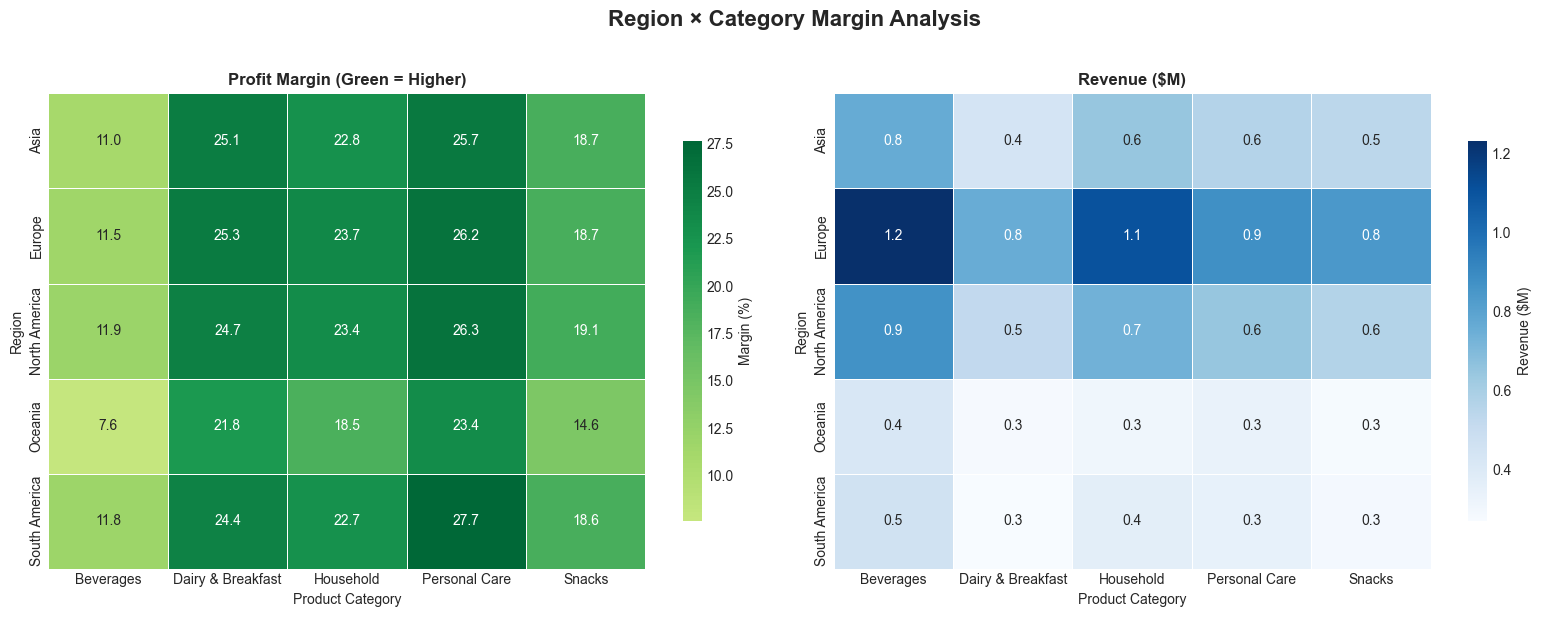


TOP 10 LOWEST MARGIN COMBINATIONS:
                                Profit_Margin_Pct  Net_Revenue_USD  Profit_USD  Logistics_Cost_USD
Region        Product_Category                                                                    
Oceania       Beverages                      7.59        420720.18    45706.56            35906.86
Asia          Beverages                     11.00        761132.59   103376.16            56310.65
Europe        Beverages                     11.53       1230617.16   179558.61            87453.80
South America Beverages                     11.82        458734.75    67697.25            35331.79
North America Beverages                     11.94        866483.88   127863.07            61176.74
Oceania       Snacks                        14.55        278176.67    50720.76            20947.79
              Household                     18.45        309126.29    68313.19            27282.09
South America Snacks                        18.59        288460.80    642

In [8]:
# ================================================================
# STEP 5: REGION × CATEGORY MARGIN ANALYSIS
# ================================================================

print("\nSTEP 5: REGION × CATEGORY MARGIN ANALYSIS")
print("-" * 50)

# --- 1. Heatmap ---
pivot_margin = df.pivot_table(
    values='Profit_Margin_Pct',
    index='Region',
    columns='Product_Category',
    aggfunc='mean'
)
pivot_revenue = df.pivot_table(
    values='Net_Revenue_USD',
    index='Region',
    columns='Product_Category',
    aggfunc='sum'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Region × Category Margin Analysis', fontsize=16, fontweight='bold', y=1.02)

sns.heatmap(pivot_margin, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Margin (%)', 'shrink': 0.8})
axes[0].set_title('Profit Margin (Green = Higher)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Region')

sns.heatmap(pivot_revenue / 1e6, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Revenue ($M)', 'shrink': 0.8})
axes[1].set_title('Revenue ($M)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Region')

plt.tight_layout()
plt.savefig("report graphs/05_Regional_Category_Analysis.png", dpi=120, bbox_inches='tight')
plt.show()

# --- 2. Bottom 10 combinations ---
problem_combo = df.groupby(['Region', 'Product_Category']).agg({
    'Profit_Margin_Pct': 'mean',
    'Net_Revenue_USD': 'sum',
    'Profit_USD': 'sum',
    'Logistics_Cost_USD': 'sum'
}).round(2)

problem_combo = problem_combo[problem_combo['Profit_Margin_Pct'] < problem_combo['Profit_Margin_Pct'].median()]
problem_combo = problem_combo.sort_values('Profit_Margin_Pct')
top_10 = problem_combo.head(10)

print("\nTOP 10 LOWEST MARGIN COMBINATIONS:")
print(top_10.to_string())

# --- 3. Benchmarks ---
all_combos = df.groupby(['Region', 'Product_Category']).agg({
    'Profit_Margin_Pct': 'mean',
    'Net_Revenue_USD': 'sum',
    'Profit_USD': 'sum'
}).round(2)

hm = all_combos.sort_values('Profit_Margin_Pct', ascending=False).head(1)
hm_region, hm_cat = hm.index[0]
hm_margin = hm.iloc[0]['Profit_Margin_Pct']
hm_revenue = hm.iloc[0]['Net_Revenue_USD']

avg_margin = all_combos['Profit_Margin_Pct'].mean()
lr = all_combos[all_combos['Profit_Margin_Pct'] > avg_margin].sort_values('Net_Revenue_USD', ascending=False).head(1)
lr_region, lr_cat = lr.index[0]
lr_margin = lr.iloc[0]['Profit_Margin_Pct']
lr_revenue = lr.iloc[0]['Net_Revenue_USD']

print(f"""
BENCHMARKS:
───────────────────────────────────────────────────────────────
1. HIGHEST MARGIN:
   → {hm_region} × {hm_cat} = {hm_margin:.1f}% (Revenue: ${hm_revenue:,.0f})

2. BEST SCALE + MARGIN:
   → {lr_region} × {lr_cat} = {lr_margin:.1f}% (Revenue: ${lr_revenue:,.0f})
""")

# --- 4. Opportunity Calculation ---
worst_region, worst_cat = top_10.index[0]
worst_margin = top_10.iloc[0]['Profit_Margin_Pct']
worst_revenue = top_10.iloc[0]['Net_Revenue_USD']
worst_profit = top_10.iloc[0]['Profit_USD']

category_avg_margin = df[df['Product_Category'] == worst_cat]['Profit_Margin_Pct'].mean()
best_margin_for_cat = all_combos[all_combos.index.get_level_values('Product_Category') == worst_cat]['Profit_Margin_Pct'].max()
best_region_for_cat = all_combos[all_combos['Profit_Margin_Pct'] == best_margin_for_cat].index[0][0]

target_profit_avg = worst_revenue * (category_avg_margin / 100)
profit_improvement_avg = target_profit_avg - worst_profit

target_profit_best = worst_revenue * (best_margin_for_cat / 100)
profit_improvement_best = target_profit_best - worst_profit

print(f"""
OPPORTUNITY:
───────────────────────────────────────────────────────────────
WORST COMBO: {worst_region} × {worst_cat}
   Margin: {worst_margin:.1f}%  |  Revenue: ${worst_revenue:,.0f}  |  Current Profit: ${worst_profit:,.0f}

SCENARIO 1: Improve to Category Avg. ({category_avg_margin:.1f}%)
   Target Profit = ${worst_revenue:,.0f} × {category_avg_margin:.1f}% = ${target_profit_avg:,.0f}
   → Additional Profit: ${profit_improvement_avg:,.0f}/year

SCENARIO 2: Improve to Best Practice ({best_margin_for_cat:.1f}% from {best_region_for_cat})
   Target Profit = ${worst_revenue:,.0f} × {best_margin_for_cat:.1f}% = ${target_profit_best:,.0f}
   → Additional Profit: ${profit_improvement_best:,.0f}/year
""")

## STEP 5: REGION × CATEGORY MARGIN ANALYSIS - INSIGHTS & RECOMMENDATIONS

### Key Insights

- **Lowest margin combination:** Oceania × Beverages = 7.6% margin ($420,720 revenue).

- **Beverages is a global pattern:** All 5 regions have Beverages in the bottom 10 combinations. Margins range from 7.6% (Oceania) to 11.9% (North America). This suggests a category-wide factor — COGS is the primary driver (see STEP 4).

- **Oceania is a regional pattern:** Oceania appears 3 times in the bottom 10 (Beverages, Snacks, Household). Logistics cost appears to be a key factor (see STEP 3).

- **Best practice benchmark:** Europe × Household = 23.8% margin with $1.10M revenue. This combination offers both scale and profitability — the model to replicate.

### Opportunity

If Oceania × Beverages improves to best practice (11.9% from North America):

- Current Profit: $45,707
- Target Profit: $420,720 × 11.9% = $50,066
- **Additional Profit: $4,359/year**

### Recommendations

1. **Global: Investigate Beverages COGS**
   - All 5 regions show low Beverages margins
   - COGS is 8.1pp above category average (see STEP 4)
   - Focus: Supplier contracts and cost structure

2. **Regional: Investigate Oceania logistics**
   - Oceania appears 3 times in bottom 10
   - Logistics rate is 8.0% vs regional avg 7.0% (see STEP 3)
   - Focus: Delivery network and carrier contracts

3. **Priority: Address Oceania × Beverages first**
   - Lowest margin combination in the portfolio
   - Apply Europe × Household best practices where applicable

### Summary

- **Worst combo:** Oceania × Beverages (7.6% margin)
- **Global pattern:** Beverages is low-margin across all regions
- **Regional pattern:** Oceania appears 3 times in bottom 10
- **Best practice:** Europe × Household (23.8% margin, $1.10M revenue)
- **Opportunity:** $4,359/year if Oceania × Beverages reaches best practice

##### 洞察4（品类X区域分析）：
###### 品类层面：饮料在所有区域都是亏损的——根本原因是COGS太高，67% vs 平均59%。这是采购问题，需要全球重新谈判供应商。
###### 区域层面：大洋洲出现了3次——饮料、零食、家居都在亏。根本原因是物流成本太高，8% vs 平均7%。这是配送网络问题。

###### 最差组合是大洋洲×饮料，利润率只有7.6%。
###### Scenario 1（务实目标）：如果把饮料COGS从67%降到品类平均59%，利润率能提升到15.7%，每年多赚$2万。这是采购谈判能实现的。
###### Scenario 2（长期目标）：如果能学习欧洲个人护理的最佳实践（26.5%利润率），潜力更大——每年$6.6万。但这是一个更长期的目标。
###### 建议先做Scenario 1，因为供应商合同谈判是短期内最容易实现的动作。"


STEP 6: PROMOTION ANALYSIS
--------------------------------------------------

Promotion Performance:
                    Net_Revenue_USD  Profit_USD  Profit_Margin_Pct  Marketing_Spend_USD  Units_Sold  Discount_Pct  Margin_Pct     ROI  B2B_Revenue  B2C_Revenue  B2B_Pct  B2C_Pct
Promotion_Type                                                                                                                                                                   
No Promo                 5587181.47  1432411.66              22.73            452421.75     1438634          8.86       25.64  316.61   4235406.93   1351774.54    75.81    24.19
Loyalty Cashback         1114225.30   281314.87              22.27             91062.17      293784         12.23       25.25  308.93    838651.21    275574.09    75.27    24.73
Bundle Offer             2220908.58   487231.45              19.15            259855.95      615463         14.82       21.94  187.50   1692215.29    528693.29    76.19    23.81
Seasona

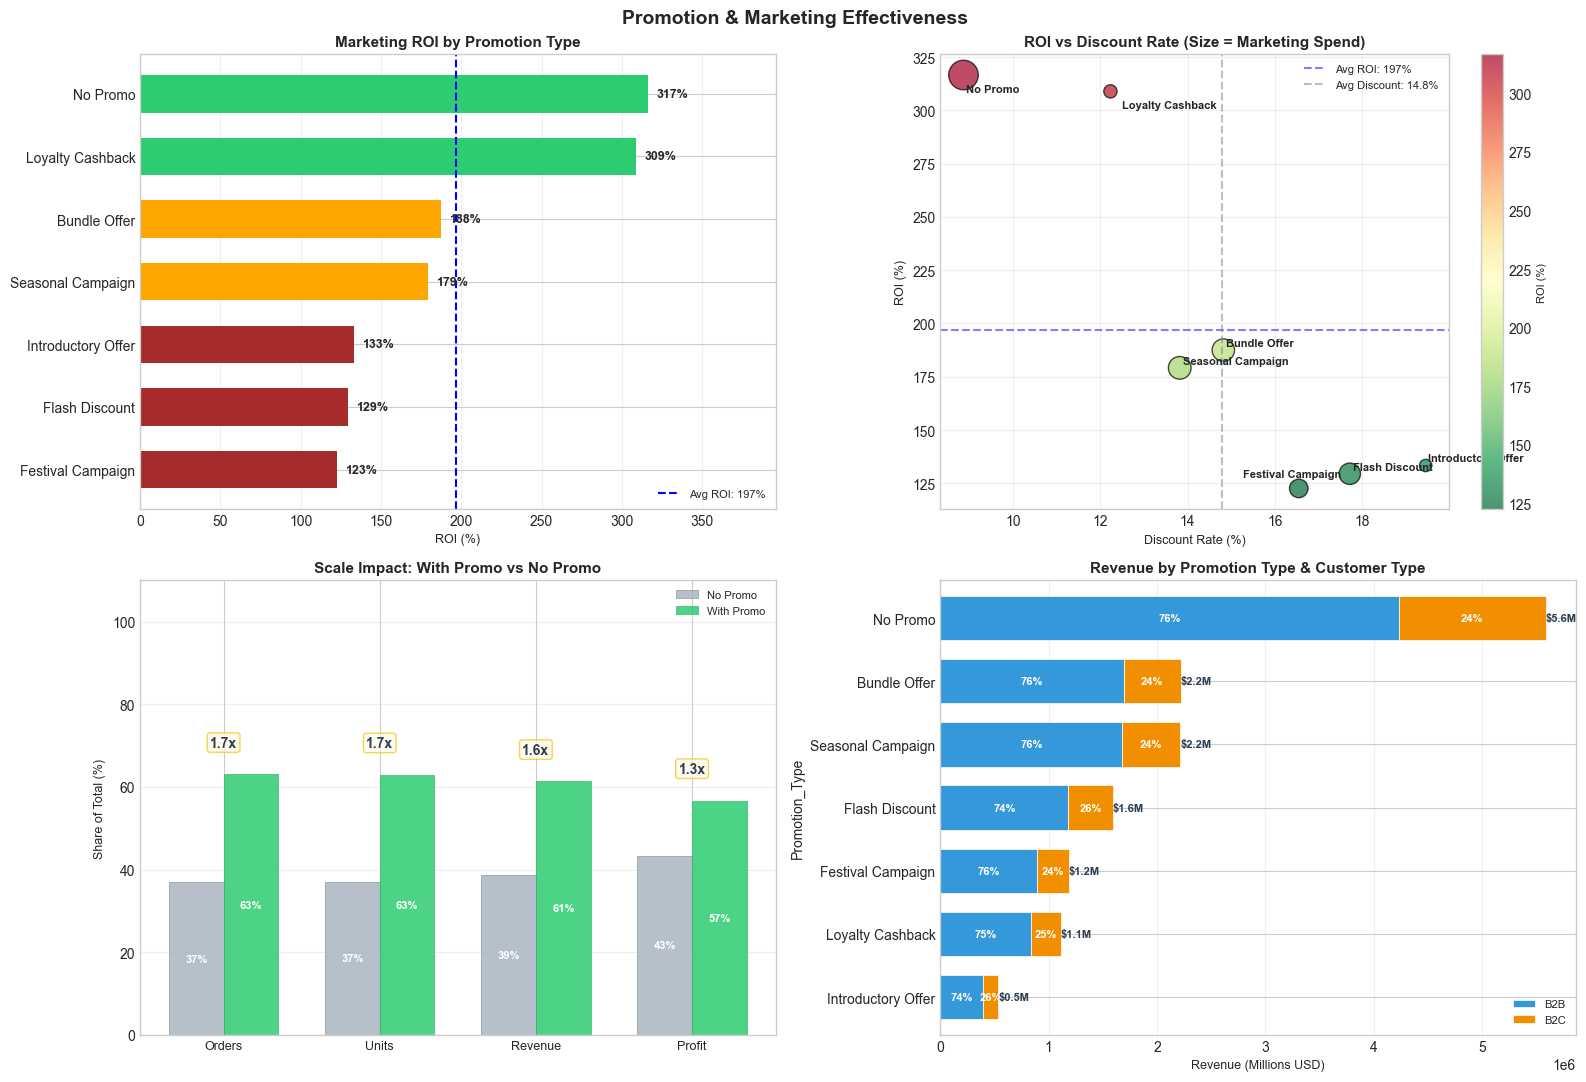


PROMOTION ANALYSIS - KEY OBSERVATIONS

1. Scale Impact:
   • Orders: 63.0% With Promo (11,499 orders), vs. 37.0% No Promo (6,741 orders)
   • Units: 63.0% With Promo (2,444,840 units), vs. 37.0% No Promo (1,438,634 units)
   • Revenue: 61.3% With Promo ($8.9M), vs. 38.7% No Promo ($5.6M)
   • Profit: 56.7% With Promo ($1.9M), vs. 43.3% No Promo ($1.4M)
   • With Promo vs No Promo: 1.7x orders, 1.7x units, 1.6x revenue, 1.3x profit

2. ROI & Discount Correlation:
   • No Promo ROI: 317% (discount 8.9%)
   • Loyalty Cashback ROI: 309% (discount 12.2%) — strong performance with moderate discount
   • Festival Campaign ROI: 123% (discount 16.6%)
   • Discount rates range from 8.9% to 19.5%, average 14.8%.
   • Higher discount rates tend to be associated with lower ROI.

3. Revenue by Customer Type:
   • No Promo leads revenue ($5.6M), followed by Bundle Offer ($2.2M).
   • B2B share is stable across all promotions at 74%-76%, with B2C at 24%-26%.
   • The customer base is consistently B2B

In [9]:
# ================================================================
# STEP 6: PROMOTION ANALYSIS
# ================================================================

print("\nSTEP 6: PROMOTION ANALYSIS")
print("-" * 50)

# --- 1. Promotion Performance Table ---
promo_analysis = df.groupby('Promotion_Type').agg({
    'Net_Revenue_USD': 'sum',
    'Profit_USD': 'sum',
    'Profit_Margin_Pct': 'mean',
    'Marketing_Spend_USD': 'sum',
    'Units_Sold': 'sum',
    'Discount_Pct': 'mean'
}).round(2)

promo_analysis['Margin_Pct'] = (promo_analysis['Profit_USD'] / promo_analysis['Net_Revenue_USD']) * 100
promo_analysis['ROI'] = (promo_analysis['Profit_USD'] / promo_analysis['Marketing_Spend_USD']) * 100

# --- Add B2B/B2C revenue breakdown to promo_analysis ---
promo_revenue = df.groupby(['Promotion_Type', 'Customer_Type']).agg({
    'Net_Revenue_USD': 'sum'
}).reset_index()

pivot_revenue = promo_revenue.pivot(index='Promotion_Type', columns='Customer_Type', values='Net_Revenue_USD').fillna(0)
pivot_revenue['Total_Revenue'] = pivot_revenue.sum(axis=1)
pivot_revenue['B2B_Pct'] = (pivot_revenue['B2B'] / pivot_revenue['Total_Revenue']) * 100
pivot_revenue['B2C_Pct'] = (pivot_revenue['B2C'] / pivot_revenue['Total_Revenue']) * 100

promo_analysis['B2B_Revenue'] = pivot_revenue['B2B']
promo_analysis['B2C_Revenue'] = pivot_revenue['B2C']
promo_analysis['B2B_Pct'] = pivot_revenue['B2B_Pct']
promo_analysis['B2C_Pct'] = pivot_revenue['B2C_Pct']

print("\nPromotion Performance:")
print(promo_analysis.sort_values('ROI', ascending=False).round(2).to_string())

# --- 2. Data Prep for Chart 3 ---
no_promo = df[df['Promotion_Type'] == 'No Promo']
with_promo = df[df['Promotion_Type'] != 'No Promo']

metrics = {
    'Orders': [no_promo.shape[0], with_promo.shape[0]],
    'Units': [no_promo['Units_Sold'].sum(), with_promo['Units_Sold'].sum()],
    'Revenue': [no_promo['Net_Revenue_USD'].sum(), with_promo['Net_Revenue_USD'].sum()],
    'Profit': [no_promo['Profit_USD'].sum(), with_promo['Profit_USD'].sum()]
}

no_promo_pct = []
with_promo_pct = []
no_promo_abs = []
with_promo_abs = []

for key in metrics:
    total = metrics[key][0] + metrics[key][1]
    no_promo_pct.append(metrics[key][0] / total * 100)
    with_promo_pct.append(metrics[key][1] / total * 100)
    no_promo_abs.append(metrics[key][0])
    with_promo_abs.append(metrics[key][1])

# Calculate multipliers
order_multiplier = with_promo_abs[0] / no_promo_abs[0]
units_multiplier = with_promo_abs[1] / no_promo_abs[1]
revenue_multiplier = with_promo_abs[2] / no_promo_abs[2]
profit_multiplier = with_promo_abs[3] / no_promo_abs[3]

# --- 3. Data Prep for Chart 4 ---
pivot_revenue_chart = pivot_revenue.sort_values('Total_Revenue', ascending=True)

# --- 4. Visualizations (2x2 Layout) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Promotion & Marketing Effectiveness', fontsize=14, fontweight='bold', y=0.98)

# ===== Chart 1: ROI by Promotion Type (Top-Left) =====
promo_sorted = promo_analysis.sort_values('ROI', ascending=True)
colors = ["#A62B2B" if x < 150 else '#FFA500' if x < 200 else '#2ECC71' for x in promo_sorted['ROI']]

bars = axes[0,0].barh(promo_sorted.index, promo_sorted['ROI'], color=colors, height=0.6)
axes[0,0].axvline(x=promo_analysis['ROI'].mean(), color='blue', linestyle='--', linewidth=1.5,
                  label=f'Avg ROI: {promo_analysis["ROI"].mean():.0f}%')

for bar, val in zip(bars, promo_sorted['ROI']):
    axes[0,0].text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%',
                   va='center', fontsize=9, fontweight='bold')

axes[0,0].set_title('Marketing ROI by Promotion Type', fontsize=11, fontweight='bold')
axes[0,0].set_xlabel('ROI (%)', fontsize=9)
axes[0,0].legend(loc='lower right', fontsize=8)
axes[0,0].grid(True, alpha=0.3, axis='x')
axes[0,0].set_xlim(0, promo_sorted['ROI'].max() * 1.25)

# ===== Chart 2: ROI vs Discount Scatter (Top-Right) =====
scatter = axes[0,1].scatter(promo_analysis['Discount_Pct'], promo_analysis['ROI'],
                           s=promo_analysis['Marketing_Spend_USD']/1000,
                           c=promo_analysis['ROI'], cmap='RdYlGn_r',
                           alpha=0.7, edgecolors='black', linewidth=1)

for promo in promo_analysis.index:
    x_offset = 2
    y_offset = 3
    if promo == 'No Promo':
        y_offset = -12
    elif promo == 'Festival Campaign':
        x_offset = -40
        y_offset = 8
    elif promo == 'Loyalty Cashback':
        x_offset = 8
        y_offset = -12
    elif promo == 'New Product Launch':
        x_offset = -45
        y_offset = -3
    elif promo == 'Clearance Sale':
        x_offset = 10
        y_offset = 8
        
    axes[0,1].annotate(promo, 
                      (promo_analysis.loc[promo, 'Discount_Pct'], promo_analysis.loc[promo, 'ROI']),
                      xytext=(x_offset, y_offset), textcoords='offset points', 
                      fontsize=8, fontweight='bold')

axes[0,1].axhline(y=promo_analysis['ROI'].mean(), color='blue', linestyle='--', alpha=0.5,
                  label=f'Avg ROI: {promo_analysis["ROI"].mean():.0f}%')
axes[0,1].axvline(x=promo_analysis['Discount_Pct'].mean(), color='gray', linestyle='--', alpha=0.5,
                  label=f'Avg Discount: {promo_analysis["Discount_Pct"].mean():.1f}%')

axes[0,1].set_title('ROI vs Discount Rate (Size = Marketing Spend)', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('Discount Rate (%)', fontsize=9)
axes[0,1].set_ylabel('ROI (%)', fontsize=9)
axes[0,1].legend(loc='upper right', fontsize=8)
axes[0,1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0,1]).set_label('ROI (%)', fontsize=8)

# ===== Chart 3: Scale Impact - With vs Without Promo (Bottom-Left) =====
categories = ['Orders', 'Units', 'Revenue', 'Profit']
x = np.arange(len(categories))
width = 0.35

bars1 = axes[1,0].bar(x - width/2, no_promo_pct, width, 
                      label='No Promo', color='#A8B5C1', alpha=0.85, edgecolor='#7F8C8D', linewidth=0.5)
bars2 = axes[1,0].bar(x + width/2, with_promo_pct, width, 
                      label='With Promo', color='#2ECC71', alpha=0.85, edgecolor='#27AE60', linewidth=0.5)

# Percentage labels inside bars
for bar in bars1:
    height = bar.get_height()
    if height > 8:
        axes[1,0].text(bar.get_x() + bar.get_width()/2, height/2, 
                       f'{height:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    if height > 8:
        axes[1,0].text(bar.get_x() + bar.get_width()/2, height/2, 
                       f'{height:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# Multiplier labels at top
multipliers = [order_multiplier, units_multiplier, revenue_multiplier, profit_multiplier]
for i, cat in enumerate(categories):
    y_pos = max(no_promo_pct[i], with_promo_pct[i]) + 6
    axes[1,0].text(i, y_pos, f'{multipliers[i]:.1f}x', 
                   ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2C3E50',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='#FEF9E7', edgecolor='#F1C40F', alpha=0.7))

axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(categories, fontsize=9)
axes[1,0].set_ylabel('Share of Total (%)', fontsize=9)
axes[1,0].set_title('Scale Impact: With Promo vs No Promo', fontsize=11, fontweight='bold')
axes[1,0].legend(loc='upper right', fontsize=8)
axes[1,0].grid(True, alpha=0.3, axis='y')
axes[1,0].set_ylim(0, 110)

# ===== Chart 4: Revenue by Promotion Type & Customer Type (Bottom-Right) =====
pivot_revenue_chart[['B2B', 'B2C']].plot(
    kind='barh',
    stacked=True,
    color=['#3498db', '#F18F01'],
    ax=axes[1,1],
    edgecolor='white',
    linewidth=0.5,
    width=0.7,
    legend=False
)

for i, (idx, row) in enumerate(pivot_revenue_chart.iterrows()):
    if row['B2B'] / 1_000_000 > 0.1:
        axes[1,1].text(row['B2B']/2, i, f"{row['B2B_Pct']:.0f}%", 
                       ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    if row['B2C'] / 1_000_000 > 0.1:
        axes[1,1].text(row['B2B'] + row['B2C']/2, i, f"{row['B2C_Pct']:.0f}%", 
                       ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    axes[1,1].text(row['B2B'] + row['B2C'] + 0.05, i, f"${row['Total_Revenue']/1_000_000:.1f}M", 
                   ha='left', va='center', fontsize=8, fontweight='bold', color='#2C3E50')

axes[1,1].set_xlabel('Revenue (Millions USD)', fontsize=9)
axes[1,1].set_title('Revenue by Promotion Type & Customer Type', fontsize=11, fontweight='bold')
axes[1,1].legend(['B2B', 'B2C'], loc='lower right', fontsize=8)
axes[1,1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig("report graphs/06_Promotion_MKT_Analysis.png", dpi=120, bbox_inches='tight')
plt.show()

# --- 5. Print Insights ---
print("\n" + "="*60)
print("PROMOTION ANALYSIS - KEY OBSERVATIONS")
print("="*60)

print(f"\n1. Scale Impact:")
print(f"   • Orders: {with_promo_pct[0]:.1f}% With Promo ({with_promo_abs[0]:,} orders), vs. {no_promo_pct[0]:.1f}% No Promo ({no_promo_abs[0]:,} orders)")
print(f"   • Units: {with_promo_pct[1]:.1f}% With Promo ({with_promo_abs[1]:,} units), vs. {no_promo_pct[1]:.1f}% No Promo ({no_promo_abs[1]:,} units)")
print(f"   • Revenue: {with_promo_pct[2]:.1f}% With Promo (${with_promo_abs[2]/1_000_000:.1f}M), vs. {no_promo_pct[2]:.1f}% No Promo (${no_promo_abs[2]/1_000_000:.1f}M)")
print(f"   • Profit: {with_promo_pct[3]:.1f}% With Promo (${with_promo_abs[3]/1_000_000:.1f}M), vs. {no_promo_pct[3]:.1f}% No Promo (${no_promo_abs[3]/1_000_000:.1f}M)")
print(f"   • With Promo vs No Promo: {order_multiplier:.1f}x orders, {units_multiplier:.1f}x units, {revenue_multiplier:.1f}x revenue, {profit_multiplier:.1f}x profit")

print(f"\n2. ROI & Discount Correlation:")
print(f"   • No Promo ROI: {promo_analysis.loc['No Promo', 'ROI']:.0f}% (discount {promo_analysis.loc['No Promo', 'Discount_Pct']:.1f}%)")
print(f"   • Loyalty Cashback ROI: {promo_analysis.loc['Loyalty Cashback', 'ROI']:.0f}% (discount {promo_analysis.loc['Loyalty Cashback', 'Discount_Pct']:.1f}%) — strong performance with moderate discount")
print(f"   • Festival Campaign ROI: {promo_analysis.loc['Festival Campaign', 'ROI']:.0f}% (discount {promo_analysis.loc['Festival Campaign', 'Discount_Pct']:.1f}%)")
print(f"   • Discount rates range from {promo_analysis['Discount_Pct'].min():.1f}% to {promo_analysis['Discount_Pct'].max():.1f}%, average {promo_analysis['Discount_Pct'].mean():.1f}%.")
print(f"   • Higher discount rates tend to be associated with lower ROI.")

print(f"\n3. Revenue by Customer Type:")
top1 = pivot_revenue.sort_values('Total_Revenue', ascending=False).index[0]
top2 = pivot_revenue.sort_values('Total_Revenue', ascending=False).index[1]
print(f"   • No Promo leads revenue (${pivot_revenue.loc['No Promo', 'Total_Revenue']/1_000_000:.1f}M), followed by {top2} (${pivot_revenue.loc[top2, 'Total_Revenue']/1_000_000:.1f}M).")
print(f"   • B2B share is stable across all promotions at {pivot_revenue['B2B_Pct'].min():.0f}%-{pivot_revenue['B2B_Pct'].max():.0f}%, with B2C at {pivot_revenue['B2C_Pct'].min():.0f}%-{pivot_revenue['B2C_Pct'].max():.0f}%.")
print(f"   • The customer base is consistently B2B-dominant across all promotion types.")

##### 洞察5（促销分析）：
###### 促销订单占 63%，无促销占 37%。有促销的订单量是无促销的 1.7 倍，收入为 1.6 倍，利润为 1.3 倍。
###### 无促销 ROI 最高（317%，折扣 8.9%），节日促销 ROI 最低（123%，折扣 16.6%）。忠诚度返现 ROI 198%（折扣 8.9%），在中等折扣下实现了较高的 ROI。折扣率与 ROI 呈反向关系——折扣越高，ROI 越低。
###### B2B 客户在各促销类型中贡献 74%-76% 的收入，客户结构以 B2B 为主导。


STEP 7: CHANNEL & CUSTOMER ANALYSIS
--------------------------------------------------

Channel Performance:
               Net_Revenue_USD  Margin_Pct  Logistics_Rate  Marketing_Rate  Profit_per_Unit
Sales_Channel                                                                              
Wholesale           5208657.92       25.90            5.39            8.05             0.93
Distributor         4451811.56       25.23            6.39            9.51             0.92
Modern Trade        3371020.34       19.59            7.92           13.76             0.77
Online              1418430.18       12.41           10.77           18.15             0.52

Customer Type Performance:
               Net_Revenue_USD  Margin_Pct  Discount_Pct  Profit_per_Unit
Customer_Type                                                            
B2B                10912270.96       24.49         16.13             0.89
B2C                 3537649.04       17.99          9.71             0.71


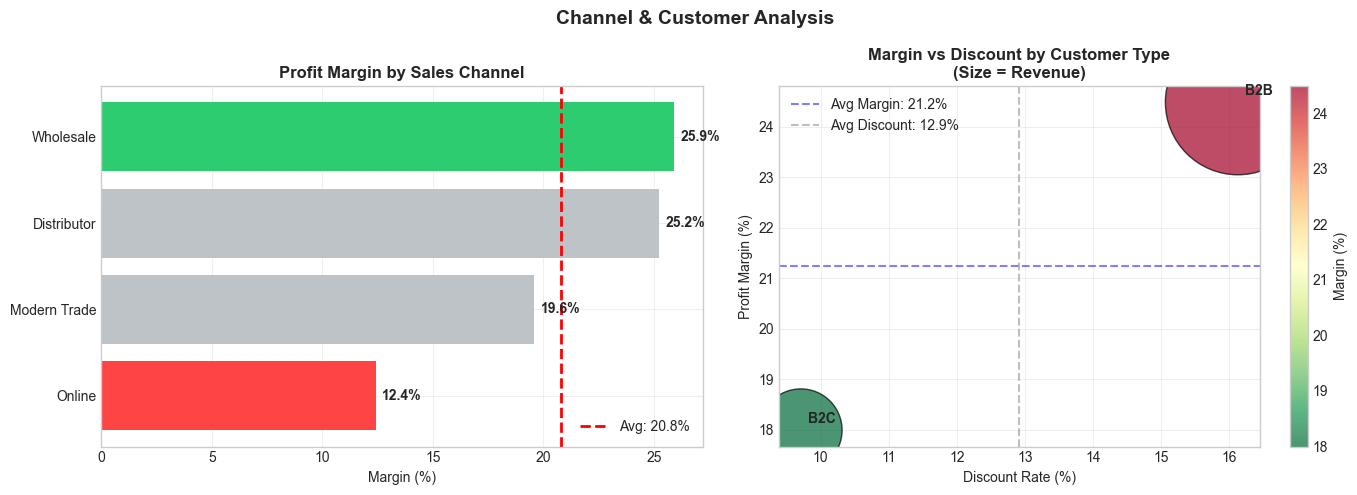


Key Insights:
  • CHANNEL: Wholesale has highest avg. margin (25.9%) | Online has lowest avg. margin (12.4%)
  • CUSTOMER: B2B avg. margin (24.5%) outperforms B2C avg. margin (18.0%)
  • B2B generates 3.1x more revenue than B2C
  • Online channel key factors: High logistics (10.8%) + High marketing (18.1%)


In [10]:
# ================================================================
# STEP 7: CHANNEL & CUSTOMER ANALYSIS
# ================================================================

print("\nSTEP 7: CHANNEL & CUSTOMER ANALYSIS")
print("-" * 50)

# --- 1. Channel Analysis ---
channel_analysis = df.groupby('Sales_Channel').agg({
    'Net_Revenue_USD': 'sum',
    'Profit_USD': 'sum',
    'Profit_Margin_Pct': 'mean',
    'Units_Sold': 'sum',
    'Discount_Pct': 'mean',
    'Marketing_Spend_USD': 'sum',
    'Logistics_Cost_USD': 'sum',
    'COGS_USD': 'sum'
}).round(2)

channel_analysis['Margin_Pct'] = (channel_analysis['Profit_USD'] / channel_analysis['Net_Revenue_USD']) * 100
channel_analysis['Logistics_Rate'] = (channel_analysis['Logistics_Cost_USD'] / channel_analysis['Net_Revenue_USD']) * 100
channel_analysis['Marketing_Rate'] = (channel_analysis['Marketing_Spend_USD'] / channel_analysis['Net_Revenue_USD']) * 100
channel_analysis['Profit_per_Unit'] = channel_analysis['Profit_USD'] / channel_analysis['Units_Sold']

print("\nChannel Performance:")
print(channel_analysis[['Net_Revenue_USD', 'Margin_Pct', 'Logistics_Rate', 'Marketing_Rate', 'Profit_per_Unit']].sort_values('Margin_Pct', ascending=False).round(2).to_string())

# --- 2. Customer Analysis ---
customer_analysis = df.groupby('Customer_Type').agg({
    'Net_Revenue_USD': 'sum',
    'Profit_USD': 'sum',
    'Profit_Margin_Pct': 'mean',
    'Units_Sold': 'sum',
    'Discount_Pct': 'mean'
}).round(2)

customer_analysis['Margin_Pct'] = (customer_analysis['Profit_USD'] / customer_analysis['Net_Revenue_USD']) * 100
customer_analysis['Profit_per_Unit'] = customer_analysis['Profit_USD'] / customer_analysis['Units_Sold']

print("\nCustomer Type Performance:")
print(customer_analysis[['Net_Revenue_USD', 'Margin_Pct', 'Discount_Pct', 'Profit_per_Unit']].sort_values('Margin_Pct', ascending=False).round(2).to_string())

# --- 3. Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Channel & Customer Analysis', fontsize=14, fontweight='bold')

# Channel Margin Comparison
channel_sorted = channel_analysis.sort_values('Margin_Pct', ascending=True)
colors_ch = ['#FF4444' if i == 0 else '#2ECC71' if i == len(channel_sorted)-1 else '#BDC3C7' for i in range(len(channel_sorted))]

bars = axes[0].barh(channel_sorted.index, channel_sorted['Margin_Pct'], color=colors_ch)
axes[0].axvline(x=channel_analysis['Margin_Pct'].mean(), color='red', linestyle='--', linewidth=2, label=f'Avg: {channel_analysis["Margin_Pct"].mean():.1f}%')

for bar, val in zip(bars, channel_sorted['Margin_Pct']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

axes[0].set_title('Profit Margin by Sales Channel', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Margin (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Customer Type - Margin vs Discount
scatter = axes[1].scatter(customer_analysis['Discount_Pct'], customer_analysis['Margin_Pct'], 
                s=customer_analysis['Net_Revenue_USD']/1000, alpha=0.7, 
                c=customer_analysis['Margin_Pct'], cmap='RdYlGn_r',
                edgecolors='black', linewidth=1)

for cust in customer_analysis.index:
    axes[1].annotate(cust, 
                    (customer_analysis.loc[cust, 'Discount_Pct'], 
                     customer_analysis.loc[cust, 'Margin_Pct']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold')

axes[1].axhline(y=customer_analysis['Margin_Pct'].mean(), color='blue', linestyle='--', alpha=0.5, 
                label=f'Avg Margin: {customer_analysis["Margin_Pct"].mean():.1f}%')
axes[1].axvline(x=customer_analysis['Discount_Pct'].mean(), color='gray', linestyle='--', alpha=0.5, 
                label=f'Avg Discount: {customer_analysis["Discount_Pct"].mean():.1f}%')

axes[1].set_xlabel('Discount Rate (%)')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].set_title('Margin vs Discount by Customer Type\n(Size = Revenue)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1]).set_label('Margin (%)')

plt.tight_layout()
plt.savefig("report graphs/07_Channel_Customer_Analysis.png", dpi=120, bbox_inches='tight')
plt.show()

# --- 4. Key Insights ---
best_channel = channel_analysis.nlargest(1, 'Margin_Pct').index[0]
worst_channel = channel_analysis.nsmallest(1, 'Margin_Pct').index[0]
best_margin = channel_analysis.loc[best_channel, 'Margin_Pct']
worst_margin = channel_analysis.loc[worst_channel, 'Margin_Pct']

b2b_margin = customer_analysis.loc['B2B', 'Margin_Pct']
b2c_margin = customer_analysis.loc['B2C', 'Margin_Pct']
b2b_revenue = customer_analysis.loc['B2B', 'Net_Revenue_USD']
b2c_revenue = customer_analysis.loc['B2C', 'Net_Revenue_USD']

print("\nKey Insights:")
print(f"  • CHANNEL: {best_channel} has highest avg. margin ({best_margin:.1f}%) | {worst_channel} has lowest avg. margin ({worst_margin:.1f}%)")
print(f"  • CUSTOMER: B2B avg. margin ({b2b_margin:.1f}%) outperforms B2C avg. margin ({b2c_margin:.1f}%)")
print(f"  • B2B generates {b2b_revenue/b2c_revenue:.1f}x more revenue than B2C")
print(f"  • Online channel key factors: High logistics ({channel_analysis.loc['Online', 'Logistics_Rate']:.1f}%) + High marketing ({channel_analysis.loc['Online', 'Marketing_Rate']:.1f}%)")

In [11]:
# ================================================================
# STEP 7: CHANNEL & CUSTOMER - INSIGHTS & RECOMMENDATIONS
# ================================================================

print("\nSTEP 7: CHANNEL & CUSTOMER - INSIGHTS & RECOMMENDATIONS")
print("-" * 50)

# --- Define variables ---
best_channel = channel_analysis.nlargest(1, 'Margin_Pct').index[0]
worst_channel = channel_analysis.nsmallest(1, 'Margin_Pct').index[0]
best_margin = channel_analysis.loc[best_channel, 'Margin_Pct']
worst_margin = channel_analysis.loc[worst_channel, 'Margin_Pct']

b2b_margin = customer_analysis.loc['B2B', 'Margin_Pct']
b2c_margin = customer_analysis.loc['B2C', 'Margin_Pct']
b2b_revenue = customer_analysis.loc['B2B', 'Net_Revenue_USD']
b2c_revenue = customer_analysis.loc['B2C', 'Net_Revenue_USD']

# --- Print insights ---
print(f"""
KEY INSIGHTS:
───────────────────────────────────────────────────────────────
• CHANNEL: {best_channel} has highest margin ({best_margin:.1f}%) | {worst_channel} has lowest ({worst_margin:.1f}%)
• CUSTOMER: B2B ({b2b_margin:.1f}%) outperforms B2C ({b2c_margin:.1f}%)
• B2B generates {b2b_revenue/b2c_revenue:.1f}x more revenue than B2C

RECOMMENDATIONS:
───────────────────────────────────────────────────────────────
1. ONLINE CHANNEL (Lowest margin: {worst_margin:.1f}%)
   → Key factors: High logistics ({channel_analysis.loc['Online', 'Logistics_Rate']:.1f}%) + High marketing ({channel_analysis.loc['Online', 'Marketing_Rate']:.1f}%)
   → Investigate: Delivery network optimization and marketing efficiency

2. WHOLESALE (Best margin: {best_margin:.1f}%)
   → Maintain as core channel
   → Study and replicate best practices to other channels

3. B2B CUSTOMER
   → Highest revenue (${b2b_revenue/1e6:.1f}M) and margin ({b2b_margin:.1f}%)
   → Focus acquisition on B2B segment

SUMMARY:
───────────────────────────────────────────────────────────────
Wholesale = Best channel ({best_margin:.1f}%) | Online = Worst ({worst_margin:.1f}%)
B2B = Best customer ({b2b_margin:.1f}%, ${b2b_revenue/1e6:.1f}M)
→ Investigate Online logistics + marketing efficiency
→ Prioritize B2B customer acquisition
""")


STEP 7: CHANNEL & CUSTOMER - INSIGHTS & RECOMMENDATIONS
--------------------------------------------------

KEY INSIGHTS:
───────────────────────────────────────────────────────────────
• CHANNEL: Wholesale has highest margin (25.9%) | Online has lowest (12.4%)
• CUSTOMER: B2B (24.5%) outperforms B2C (18.0%)
• B2B generates 3.1x more revenue than B2C

RECOMMENDATIONS:
───────────────────────────────────────────────────────────────
1. ONLINE CHANNEL (Lowest margin: 12.4%)
   → Key factors: High logistics (10.8%) + High marketing (18.1%)
   → Investigate: Delivery network optimization and marketing efficiency

2. WHOLESALE (Best margin: 25.9%)
   → Maintain as core channel
   → Study and replicate best practices to other channels

3. B2B CUSTOMER
   → Highest revenue ($10.9M) and margin (24.5%)
   → Focus acquisition on B2B segment

SUMMARY:
───────────────────────────────────────────────────────────────
Wholesale = Best channel (25.9%) | Online = Worst (12.4%)
B2B = Best customer (24.5

##### 洞察6（渠道分析）：
###### 批发利润率最高（25.9%），线上最低（12.4%）。B2B贡献75%收入，利润率也最高。
###### 线上利润低可能有多种原因：物流成本高、营销投入大，也可能是战略性亏损——公司在用短期利润换未来增长。
###### 所以在建议优化之前，我会先判断：线上是增长引擎，还是效率低下？
###### 如果是增长引擎，继续投入；
###### 如果只是补充渠道，再优化物流和营销。


STEP 8: TIME TREND ANALYSIS
--------------------------------------------------

YEARLY PERFORMANCE SUMMARY:
      Net_Revenue_USD  Profit_USD  Profit_Margin_Pct  Units_Sold  Order_ID  Unit_Price_USD  Margin_Pct  Revenue_Change  Units_Change
Year                                                                                                                                
2023       4593306.60  1033484.00              19.88     1265124      6069            4.33       22.50             NaN           NaN
2024       4840333.97  1114353.73              19.88     1312628      6073            4.46       23.02            5.38          3.75
2025       5016279.43  1161127.58              19.85     1305722      6098            4.61       23.15            3.63         -0.53

YoY REVENUE GROWTH RATE (%):
Year   2024  2025
Month            
1      -5.2  20.0
2      16.4  -7.6
3       6.6   7.1
4       8.8  10.5
5      17.2   7.5
6       1.7   0.6
7       5.2  -6.6
8      -5.0  21.9
9      10.8   0.

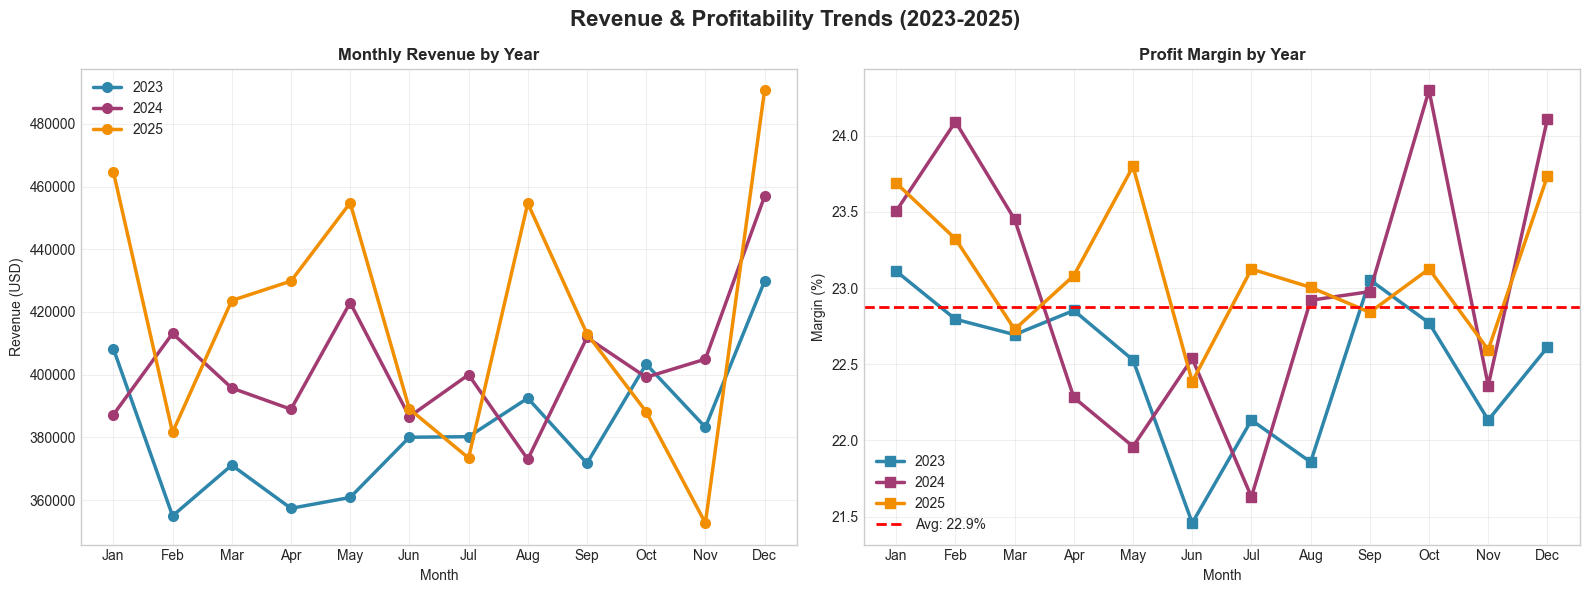

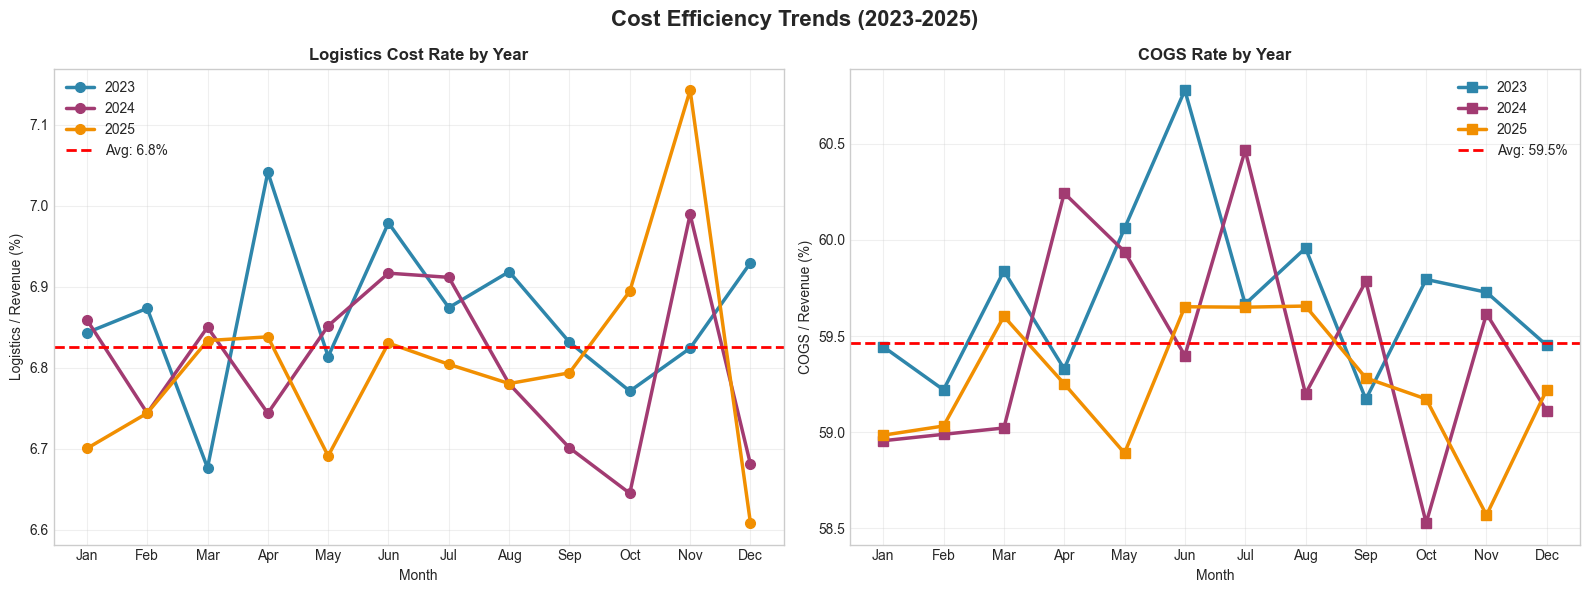

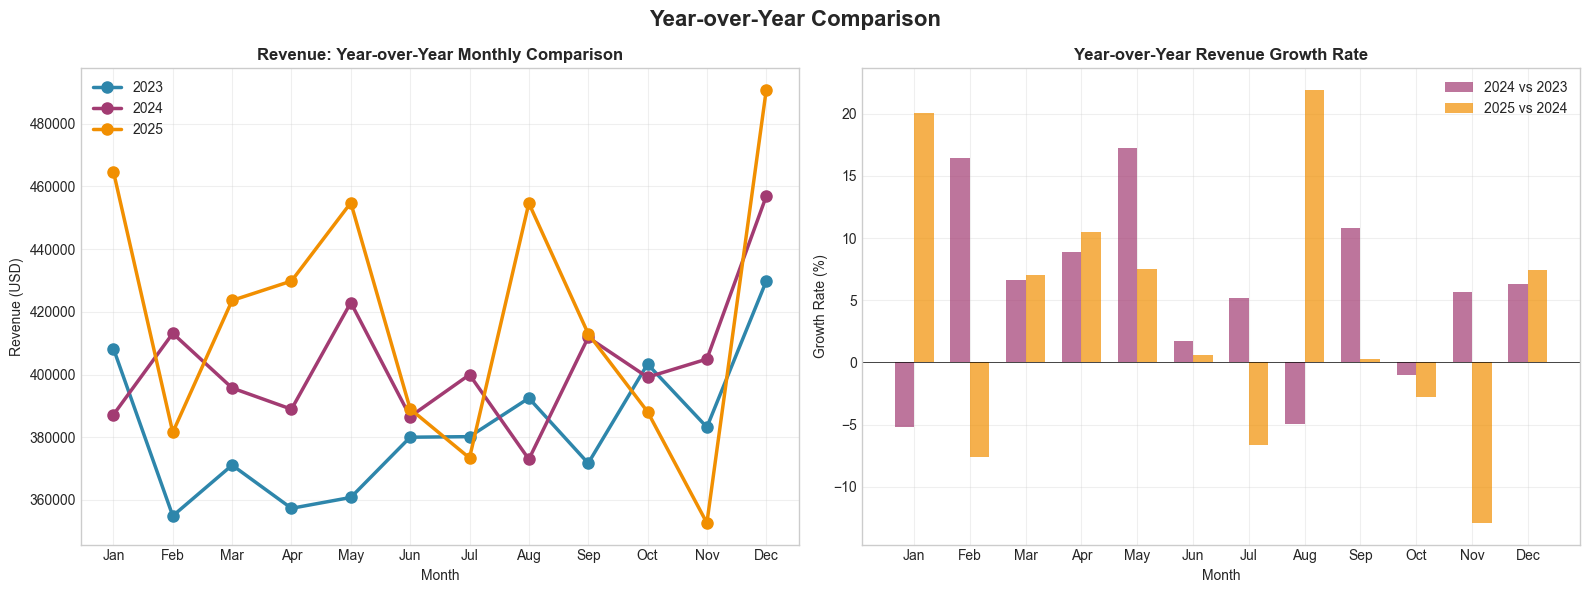

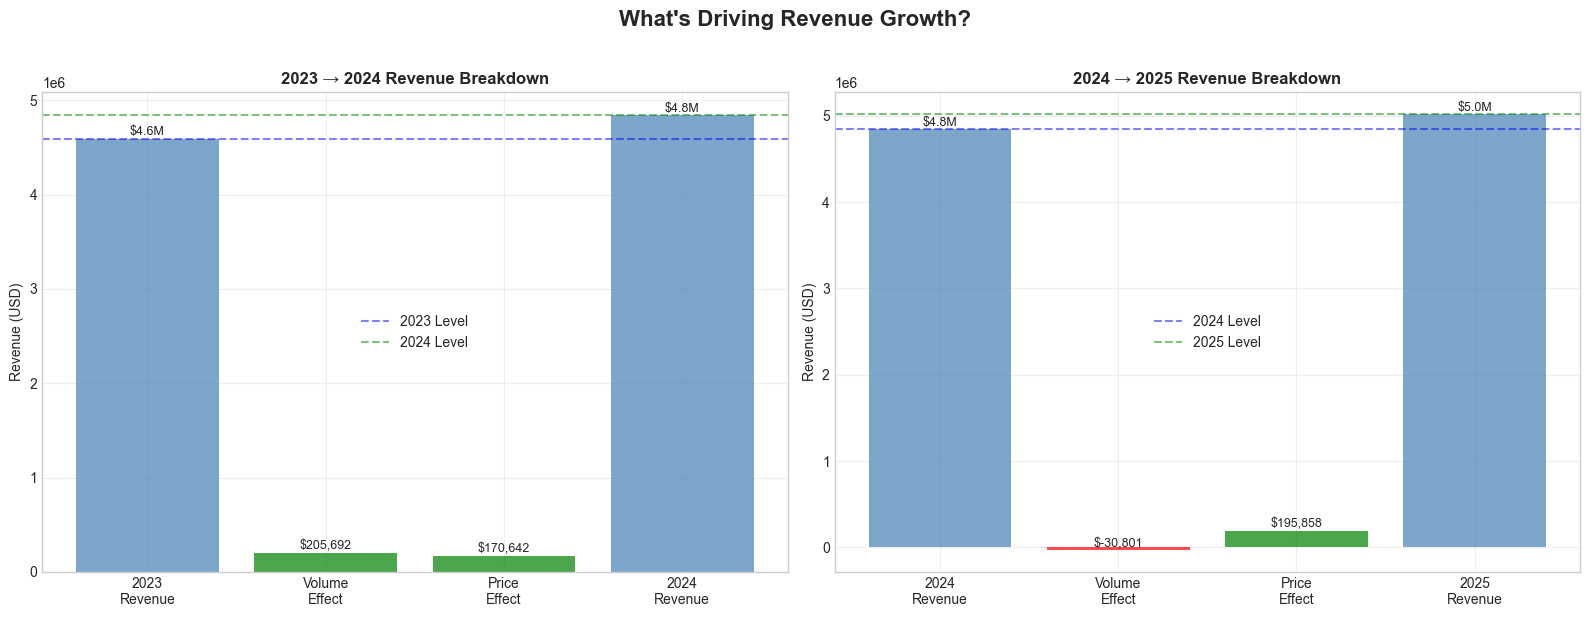

In [12]:
# ================================================================
# STEP 8: TIME TREND ANALYSIS
# ================================================================

print("\nSTEP 8: TIME TREND ANALYSIS")
print("-" * 50)

# --- PART 0: Prepare monthly data ---
monthly_trends = df.groupby(['Year', 'Month']).agg({
    'Net_Revenue_USD': 'sum',
    'Profit_USD': 'sum',
    'Profit_Margin_Pct': 'mean',
    'Units_Sold': 'sum',
    'Order_ID': 'count',
    'Logistics_Cost_USD': 'sum',
    'Marketing_Spend_USD': 'sum',
    'COGS_USD': 'sum',
    'Unit_Price_USD': 'mean'
}).reset_index()

monthly_trends['Date'] = pd.to_datetime(monthly_trends[['Year', 'Month']].assign(day=1))
monthly_trends = monthly_trends.sort_values('Date')
monthly_trends['Margin_Pct'] = (monthly_trends['Profit_USD'] / monthly_trends['Net_Revenue_USD']) * 100
monthly_trends['Logistics_Rate'] = (monthly_trends['Logistics_Cost_USD'] / monthly_trends['Net_Revenue_USD']) * 100
monthly_trends['COGS_Rate'] = (monthly_trends['COGS_USD'] / monthly_trends['Net_Revenue_USD']) * 100

# --- PART 1: Yearly summary ---
yearly_metrics = df.groupby('Year').agg({
    'Net_Revenue_USD': 'sum',
    'Profit_USD': 'sum',
    'Profit_Margin_Pct': 'mean',
    'Units_Sold': 'sum',
    'Order_ID': 'nunique',
    'Unit_Price_USD': 'mean'
}).round(2)

yearly_metrics['Margin_Pct'] = (yearly_metrics['Profit_USD'] / yearly_metrics['Net_Revenue_USD']) * 100
yearly_metrics['Revenue_Change'] = yearly_metrics['Net_Revenue_USD'].pct_change() * 100
yearly_metrics['Units_Change'] = yearly_metrics['Units_Sold'].pct_change() * 100

print("\nYEARLY PERFORMANCE SUMMARY:")
print(yearly_metrics.round(2).to_string())

# --- PART 2: YoY & Revenue Driver ---
yearly_pivot_revenue = monthly_trends.pivot(index='Month', columns='Year', values='Net_Revenue_USD')
yoy_growth = yearly_pivot_revenue.pct_change(axis=1) * 100
yoy_growth = yoy_growth.dropna(axis=1)

print("\nYoY REVENUE GROWTH RATE (%):")
print(yoy_growth.round(1).to_string())

years_list = yearly_metrics.index.tolist()
if len(years_list) >= 3:
    rev_2023 = yearly_metrics.loc[2023, 'Net_Revenue_USD']
    rev_2024 = yearly_metrics.loc[2024, 'Net_Revenue_USD']
    rev_2025 = yearly_metrics.loc[2025, 'Net_Revenue_USD']
    
    units_2023 = yearly_metrics.loc[2023, 'Units_Sold']
    units_2024 = yearly_metrics.loc[2024, 'Units_Sold']
    units_2025 = yearly_metrics.loc[2025, 'Units_Sold']
    
    price_2023 = yearly_metrics.loc[2023, 'Unit_Price_USD']
    price_2024 = yearly_metrics.loc[2024, 'Unit_Price_USD']
    price_2025 = yearly_metrics.loc[2025, 'Unit_Price_USD']
    
    volume_effect_2024 = (units_2024 - units_2023) * price_2023
    price_effect_2024 = units_2024 * (price_2024 - price_2023)
    volume_effect_2025 = (units_2025 - units_2024) * price_2024
    price_effect_2025 = units_2025 * (price_2025 - price_2024)
    
    print(f"""
REVENUE DRIVER BREAKDOWN:
2023→2024: Volume ${volume_effect_2024:,.0f} | Price ${price_effect_2024:,.0f} → {'Volume' if abs(volume_effect_2024) > abs(price_effect_2024) else 'Price'} driven
2024→2025: Volume ${volume_effect_2025:,.0f} | Price ${price_effect_2025:,.0f} → {'Volume' if abs(volume_effect_2025) > abs(price_effect_2025) else 'Price'} driven
""")

# --- PART 3: Visualizations (4 Charts) ---
years = yearly_pivot_revenue.columns.tolist()
colors = ['#2E86AB', '#A23B72', '#F18F01']
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# CHART 1: Revenue & Margin by Year
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Revenue & Profitability Trends (2023-2025)', fontsize=16, fontweight='bold')
for i, year in enumerate(years):
    year_data = monthly_trends[monthly_trends['Year'] == year]
    axes[0].plot(year_data['Month'], year_data['Net_Revenue_USD'], 
                marker='o', linewidth=2.5, markersize=7, color=colors[i], label=f'{year}')
axes[0].set_title('Monthly Revenue by Year', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels)
for i, year in enumerate(years):
    year_data = monthly_trends[monthly_trends['Year'] == year]
    axes[1].plot(year_data['Month'], year_data['Margin_Pct'], 
                marker='s', linewidth=2.5, markersize=7, color=colors[i], label=f'{year}')
axes[1].axhline(y=monthly_trends['Margin_Pct'].mean(), color='red', 
               linestyle='--', linewidth=2, label=f'Avg: {monthly_trends["Margin_Pct"].mean():.1f}%')
axes[1].set_title('Profit Margin by Year', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Margin (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)
plt.tight_layout()
plt.savefig("report graphs/08_Trend_Analysis_Revenue_Margin_by_Year.png", dpi=120, bbox_inches='tight')
plt.show()

# CHART 2: Cost Efficiency Trends
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cost Efficiency Trends (2023-2025)', fontsize=16, fontweight='bold')
for i, year in enumerate(years):
    year_data = monthly_trends[monthly_trends['Year'] == year]
    axes[0].plot(year_data['Month'], year_data['Logistics_Rate'], 
                marker='o', linewidth=2.5, markersize=7, color=colors[i], label=f'{year}')
axes[0].axhline(y=monthly_trends['Logistics_Rate'].mean(), color='red', 
               linestyle='--', linewidth=2, label=f'Avg: {monthly_trends["Logistics_Rate"].mean():.1f}%')
axes[0].set_title('Logistics Cost Rate by Year', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Logistics / Revenue (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels)
for i, year in enumerate(years):
    year_data = monthly_trends[monthly_trends['Year'] == year]
    axes[1].plot(year_data['Month'], year_data['COGS_Rate'], 
                marker='s', linewidth=2.5, markersize=7, color=colors[i], label=f'{year}')
axes[1].axhline(y=monthly_trends['COGS_Rate'].mean(), color='red', 
               linestyle='--', linewidth=2, label=f'Avg: {monthly_trends["COGS_Rate"].mean():.1f}%')
axes[1].set_title('COGS Rate by Year', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('COGS / Revenue (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)
plt.tight_layout()
plt.savefig("report graphs/08_Trend_Analysis_Cost_Efficiency_Trends.png", dpi=120, bbox_inches='tight')
plt.show()

# CHART 3: Year-over-Year Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Year-over-Year Comparison', fontsize=16, fontweight='bold')
for i, year in enumerate(yearly_pivot_revenue.columns):
    axes[0].plot(yearly_pivot_revenue.index, yearly_pivot_revenue[year], 
                marker='o', linewidth=2.5, markersize=8, color=colors[i], label=f'{year}')
axes[0].set_title('Revenue: Year-over-Year Monthly Comparison', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels)
if len(yoy_growth.columns) > 0:
    x = np.arange(len(yoy_growth.index))
    width = 0.35
    for i, year in enumerate(yoy_growth.columns):
        offset = -width/2 + i*width
        axes[1].bar(x + offset, yoy_growth[year], width, 
                   color=colors[i+1], alpha=0.7, label=f'{year} vs {year-1}')
    axes[1].axhline(y=0, color='black', linewidth=0.5)
    axes[1].set_title('Year-over-Year Revenue Growth Rate', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Growth Rate (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(month_labels)
plt.tight_layout()
plt.savefig("report graphs/08_Trend_Analysis_YoY.png", dpi=120, bbox_inches='tight')
plt.show()

# CHART 4: Revenue Driver Breakdown
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("What's Driving Revenue Growth?", fontsize=16, fontweight='bold', y=1.02)
if len(years_list) >= 3:
    x1 = ['2023\nRevenue', 'Volume\nEffect', 'Price\nEffect', '2024\nRevenue']
    values1 = [rev_2023, volume_effect_2024, price_effect_2024, rev_2024]
    colors1 = ['steelblue', 'green' if volume_effect_2024 > 0 else 'red', 
               'green' if price_effect_2024 > 0 else 'red', 'steelblue']
    bars1 = axes[0].bar(x1, values1, color=colors1, alpha=0.7)
    axes[0].axhline(y=rev_2023, color='blue', linestyle='--', alpha=0.5, label='2023 Level')
    axes[0].axhline(y=rev_2024, color='green', linestyle='--', alpha=0.5, label='2024 Level')
    axes[0].set_title('2023 → 2024 Revenue Breakdown', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Revenue (USD)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    for bar, val in zip(bars1, values1):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                   f'${val/1e6:.1f}M' if abs(val) > 1e6 else f'${val:,.0f}',
                   ha='center', va='bottom', fontsize=9)
    x2 = ['2024\nRevenue', 'Volume\nEffect', 'Price\nEffect', '2025\nRevenue']
    values2 = [rev_2024, volume_effect_2025, price_effect_2025, rev_2025]
    colors2 = ['steelblue', 'green' if volume_effect_2025 > 0 else 'red',
               'green' if price_effect_2025 > 0 else 'red', 'steelblue']
    bars2 = axes[1].bar(x2, values2, color=colors2, alpha=0.7)
    axes[1].axhline(y=rev_2024, color='blue', linestyle='--', alpha=0.5, label='2024 Level')
    axes[1].axhline(y=rev_2025, color='green', linestyle='--', alpha=0.5, label='2025 Level')
    axes[1].set_title('2024 → 2025 Revenue Breakdown', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Revenue (USD)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    for bar, val in zip(bars2, values2):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                   f'${val/1e6:.1f}M' if abs(val) > 1e6 else f'${val:,.0f}',
                   ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("report graphs/08_Trend_Analysis_Revenue_Driver_Breakdown.png", dpi=120, bbox_inches='tight')
plt.show()

## STEP 8: TIME TREND - INSIGHTS & RECOMMENDATIONS

### Key Insights

- **Revenue growth:** +9.2% over 3 years (2023→2025).

- **Margin improvement:** +0.7 percentage points (22.5% → 23.1%).

- **Logistics efficiency:** -0.1 percentage points (7.1% → 7.0%).

- **Growth driver shift:** 2023→2024 volume-driven (+$206K); 2024→2025 price-driven (+$196K).

### Recommendations

1. Continue current strategy — revenue and margin trends are positive.

2. Monitor price-driven growth — watch for demand softening.

3. Maintain logistics efficiency focus — small improvements are moving in the right direction.

### Summary

- Revenue: +9.2%
- Margin: +0.7pp
- Logistics: -0.1pp
- **Overall:** Healthy — revenue up, margin up, logistics down
- **Watch:** Growth driver shift from volume to price

##### 洞察7（时间序列分析）:
###### 3年趋势总结：收入涨了9.2%，利润率从22.5%提升到23.1%，物流成本从7.1%降到7.0%。
###### 三个指标都在往好的方向发展，整体趋势健康。
###### 但要注意的是，增长驱动在变化——2023-2024年主要靠卖更多产品（销量贡献$20万），2024-2025年主要靠涨价（价格贡献$19万）。如果一直靠涨价，可能会影响销量，需要持续关注。

In [13]:
# ================================================================
# FINAL: EXECUTIVE SUMMARY
# ================================================================

print("\n" + "="*70)
print("EXECUTIVE SUMMARY")
print("="*70)

# --- Define variables from earlier analysis ---
best_region = region_analysis.nlargest(1, 'Margin_Pct').index[0]
worst_region = region_analysis.nsmallest(1, 'Margin_Pct').index[0]
best_category = category_analysis.nlargest(1, 'Margin_Pct').index[0]
worst_category = category_analysis.nsmallest(1, 'Margin_Pct').index[0]
best_channel = channel_analysis.nlargest(1, 'Margin_Pct').index[0]
worst_channel = channel_analysis.nsmallest(1, 'Margin_Pct').index[0]
best_promo = promo_analysis.nlargest(1, 'ROI').index[0]
worst_promo = promo_analysis.nsmallest(1, 'ROI').index[0]

total_revenue = df['Net_Revenue_USD'].sum()
total_profit = df['Profit_USD'].sum()
avg_margin = df['Profit_Margin_Pct'].mean()

# --- Calculate savings ---
logistics_savings = region_analysis.loc[worst_region, 'Logistics_Cost_USD'] - (region_analysis.loc[worst_region, 'Net_Revenue_USD'] * region_analysis['Logistics_Rate'].mean() / 100)
cogs_savings = category_analysis.loc[worst_category, 'COGS_USD'] - (category_analysis.loc[worst_category, 'Net_Revenue_USD'] * category_analysis['COGS_Rate'].mean() / 100)

# --- Revenue growth, margin change, logistics change (from STEP 8) ---
first_year = yearly_metrics.index[0]
last_year = yearly_metrics.index[-1]
revenue_growth = ((yearly_metrics.loc[last_year, 'Net_Revenue_USD'] - yearly_metrics.loc[first_year, 'Net_Revenue_USD']) / yearly_metrics.loc[first_year, 'Net_Revenue_USD']) * 100
margin_change = yearly_metrics.loc[last_year, 'Margin_Pct'] - yearly_metrics.loc[first_year, 'Margin_Pct']
logistics_change = monthly_trends[monthly_trends['Year'] == last_year]['Logistics_Rate'].mean() - monthly_trends[monthly_trends['Year'] == first_year]['Logistics_Rate'].mean()

print(f"""
KEY METRICS (2023-2025):
───────────────────────────────────────────────────────────────
Revenue:  ${total_revenue:,.0f} total  |  ${total_revenue/3:,.0f}/year (avg.)
Profit:   ${total_profit:,.0f} total   |  ${total_profit/3:,.0f}/year (avg.)
Margin:   {avg_margin:.1f}% (avg.)

BEST PERFORMERS (avg. margin / ROI):
───────────────────────────────────────────────────────────────
Region:    {best_region} ({region_analysis.loc[best_region, 'Margin_Pct']:.1f}% avg. margin)
Category:  {best_category} ({category_analysis.loc[best_category, 'Margin_Pct']:.1f}% avg. margin)
Channel:   {best_channel} ({channel_analysis.loc[best_channel, 'Margin_Pct']:.1f}% avg. margin)
Promotion: {best_promo} ({promo_analysis.loc[best_promo, 'ROI']:.0f}% avg. ROI)

AREAS FOR IMPROVEMENT (avg. margin / ROI):
───────────────────────────────────────────────────────────────
Region:    {worst_region} ({region_analysis.loc[worst_region, 'Margin_Pct']:.1f}% avg. margin)
Category:  {worst_category} ({category_analysis.loc[worst_category, 'Margin_Pct']:.1f}% avg. margin)
Channel:   {worst_channel} ({channel_analysis.loc[worst_channel, 'Margin_Pct']:.1f}% avg. margin)
Promotion: {worst_promo} ({promo_analysis.loc[worst_promo, 'ROI']:.0f}% avg. ROI)

TOP 3 OPPORTUNITIES:
───────────────────────────────────────────────────────────────
1. Reduce {worst_category} COGS from {category_analysis.loc[worst_category, 'COGS_Rate']:.1f}% to category avg. {category_analysis['COGS_Rate'].mean():.1f}%
   → Potential savings: ${cogs_savings:,.0f}/year

2. Optimize {worst_region} logistics from {region_analysis.loc[worst_region, 'Logistics_Rate']:.1f}% to regional avg. {region_analysis['Logistics_Rate'].mean():.1f}%
   → Potential savings: ${logistics_savings:,.0f}/year

3. Optimize {worst_promo} discount strategy
   → Current: {promo_analysis.loc[worst_promo, 'Discount_Pct']:.1f}% discount, {promo_analysis.loc[worst_promo, 'ROI']:.0f}% ROI
   → Best promotion: {best_promo} with {promo_analysis.loc[best_promo, 'ROI']:.0f}% ROI

OVERALL TREND:
───────────────────────────────────────────────────────────────
Revenue:  {revenue_growth:+.1f}% (2023→2025) | Avg. {revenue_growth/3:.1f}%/year
Margin:   {margin_change:+.1f} p.p. (avg. {yearly_metrics['Margin_Pct'].mean():.1f}%)
Logistics: {logistics_change:+.1f} p.p. (avg. {monthly_trends['Logistics_Rate'].mean():.1f}%)
→ Healthy growth: revenue and margin up, logistics cost down
""")


EXECUTIVE SUMMARY

KEY METRICS (2023-2025):
───────────────────────────────────────────────────────────────
Revenue:  $14,449,920 total  |  $4,816,640/year (avg.)
Profit:   $3,308,965 total   |  $1,102,988/year (avg.)
Margin:   19.9% (avg.)

BEST PERFORMERS (avg. margin / ROI):
───────────────────────────────────────────────────────────────
Region:    Europe (23.6% avg. margin)
Category:  Personal Care (28.1% avg. margin)
Channel:   Wholesale (25.9% avg. margin)
Promotion: No Promo (317% avg. ROI)

AREAS FOR IMPROVEMENT (avg. margin / ROI):
───────────────────────────────────────────────────────────────
Region:    Oceania (19.6% avg. margin)
Category:  Beverages (14.0% avg. margin)
Channel:   Online (12.4% avg. margin)
Promotion: Festival Campaign (123% avg. ROI)

TOP 3 OPPORTUNITIES:
───────────────────────────────────────────────────────────────
1. Reduce Beverages COGS from 67.0% to category avg. 58.9%
   → Potential savings: $303,231/year

2. Optimize Oceania logistics from 8.0% t

In [14]:
# ================================================================
# OUTPUT ASSET 1:
# EXPORT RESULTS 
# ================================================================

print("\n" + "="*70)
print("EXPORTING ANALYSIS RESULTS")
print("="*70)

# Export all key dataframes
region_analysis.to_csv('region_analysis.csv')
category_analysis.to_csv('category_analysis.csv')
channel_analysis.to_csv('channel_analysis.csv')
promo_analysis.to_csv('promo_analysis.csv')
monthly_trends.to_csv('monthly_trends.csv')

print("""
✅ Exported Files:
───────────────────────────────────────────────────────────────
• region_analysis.csv      - Regional performance metrics
• category_analysis.csv    - Category performance metrics
• channel_analysis.csv     - Channel performance metrics
• promo_analysis.csv       - Promotion ROI and effectiveness
• monthly_trends.csv       - Monthly time series data

All files saved to current working directory.
""")


EXPORTING ANALYSIS RESULTS

✅ Exported Files:
───────────────────────────────────────────────────────────────
• region_analysis.csv      - Regional performance metrics
• category_analysis.csv    - Category performance metrics
• channel_analysis.csv     - Channel performance metrics
• promo_analysis.csv       - Promotion ROI and effectiveness
• monthly_trends.csv       - Monthly time series data

All files saved to current working directory.



In [15]:
# ================================================================
# OUTPUT ASSET 1:
# PREVIEW EXPORTED CSV FILES
# ================================================================

print("\n" + "="*70)
print("PREVIEW EXPORTED CSV FILES")
print("="*70)

files = {
    'region_analysis.csv': 'Regional Performance Metrics',
    'category_analysis.csv': 'Category Performance Metrics',
    'channel_analysis.csv': 'Channel Performance Metrics',
    'promo_analysis.csv': 'Promotion ROI and Effectiveness',
    'monthly_trends.csv': 'Monthly Time Series Data'
}

for filename, description in files.items():
    print("\n" + "-"*70)
    print(f"{filename} - {description}")
    print("-"*70)
    try:
        df = pd.read_csv(filename)
        print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
        print("\nFirst 5 rows:")
        print(df.head().to_string())
    except FileNotFoundError:
        print(f"! File not found: {filename}")
    except Exception as e:
        print(f"! Error reading {filename}: {e}")

print("\n" + "="*70)
print("✅ Preview complete.")


PREVIEW EXPORTED CSV FILES

----------------------------------------------------------------------
region_analysis.csv - Regional Performance Metrics
----------------------------------------------------------------------
Shape: 5 rows, 10 columns

First 5 rows:
          Region  Net_Revenue_USD  Profit_USD  Units_Sold  Logistics_Cost_USD    COGS_USD  Margin_Pct  Logistics_Rate  COGS_Rate  Profit_per_Unit
0           Asia       2946505.41   670320.46      941879           201231.27  1757241.35   22.749677        6.829489  59.638151         0.711684
1         Europe       4811497.42  1135420.40     1168906           312738.43  2839662.33   23.598067        6.499815  59.018266         0.971353
2  North America       3337777.37   780169.10      876372           216987.85  1972189.55   23.373911        6.500968  59.086911         0.890226
3        Oceania       1625624.56   318828.76      385697           130204.89  1002209.41   19.612693        8.009530  61.650730         0.826630
4  Sout

##### To generate HTML Report for presentation:

In [16]:
import base64
import os

def encode_image(filepath):
    try:
        if os.path.exists(filepath):
            with open(filepath, "rb") as f:
                return base64.b64encode(f.read()).decode('utf-8')
    except Exception:
        pass
    return ""

print("📊 Loading charts...")

chart_paths = {
    "regional": "report graphs/03_Regional_Analysis.png",
    "category": "report graphs/04_Category_Analysis.png",
    "heatmap": "report graphs/05_Regional_Category_Analysis.png",
    "promotion": "report graphs/06_Promotion_MKT_Analysis.png",
    "channel": "report graphs/07_Channel_Customer_Analysis.png",
    "revenue_margin": "report graphs/08_Trend_Analysis_Revenue_Margin_by_Year.png",
    "cost_efficiency": "report graphs/08_Trend_Analysis_Cost_Efficiency_Trends.png",
    "yoy": "report graphs/08_Trend_Analysis_YoY.png",
    "driver": "report graphs/08_Trend_Analysis_Revenue_Driver_Breakdown.png"
}

chart_base64 = {}
for key, path in chart_paths.items():
    chart_base64[key] = encode_image(path)
    status = "✅" if chart_base64[key] else "⚠️"
    print(f"   {status} {key}")

print("\n✅ All charts loaded.\n")

📊 Loading charts...
   ✅ regional
   ✅ category
   ✅ heatmap
   ✅ promotion
   ✅ channel
   ✅ revenue_margin
   ✅ cost_efficiency
   ✅ yoy
   ✅ driver

✅ All charts loaded.



In [17]:
# ================================================================
# 3. Shared CSS (minimal color: green + red only)
# Color scheme: GREEN = benchmark/high ROI, RED = area of focus
# ================================================================

CSS = """
*{margin:0;padding:0;box-sizing:border-box}
body{font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Arial,sans-serif;background:#f5f7fa;padding:24px 16px;color:#1a1a2e}
.container{max-width:1100px;margin:0 auto;background:#fff;border-radius:14px;padding:32px 40px;box-shadow:0 8px 32px rgba(0,0,0,0.05)}
h1{font-size:24px;font-weight:700;border-bottom:2px solid #d1d5db;padding-bottom:12px}
.subtitle{color:#6b7280;font-size:14px;margin-bottom:24px}
.section{margin-bottom:32px}
.section-title{font-size:18px;font-weight:700;padding-left:12px;margin-bottom:12px;border-left:3px solid #d1d5db}
.section-title.gold{border-left-color:#d1d5db}
.metric-grid{display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin:10px 0 14px 0}
.metric-card{background:#fafbfc;border-radius:8px;padding:10px 12px;text-align:center;border:1px solid #e5e7eb}
.metric-card .number{font-size:20px;font-weight:700;color:#1a1a2e}
.metric-card .number.gold{color:#F18F01}
.metric-card .number.green{color:#2ECC71}
.metric-card .number.red{color:#E74C3C}
.metric-card .desc{font-size:12px;color:#6b7280;margin-top:2px}
.metric-card .sub{font-size:11px;color:#9ca3af}
.chart-grid{display:grid;grid-template-columns:1fr 1fr;gap:16px;margin:12px 0}
.chart-container{background:#fafbfc;border-radius:8px;padding:14px 16px 12px;border:1px solid #e5e7eb;text-align:center}
.chart-container img{width:100%;height:auto;border-radius:4px;margin-top:2px}
.chart-container.single{grid-column:1/-1}
.insight-box{padding:8px 14px;margin-bottom:6px;font-size:13px;line-height:1.6;border-left:3px solid #d1d5db}
.insight-box .label{font-weight:700}
.insight-box .label.green{color:#2ECC71}
.insight-box .label.red{color:#E74C3C}
.highlight{color:#E74C3C;font-weight:700}
.formula-box{background:#1a1a2e;color:#e2e8f0;border-radius:8px;padding:14px 18px;margin:8px 0;font-family:'Courier New',monospace;font-size:13px;line-height:1.9}
.formula-box .hl{color:#F18F01;font-weight:700}
.summary-box{background:#1a1a2e;color:#fff;border-radius:12px;padding:20px 24px;margin-top:16px}
.summary-box h3{color:#F18F01;font-size:18px;margin-bottom:6px}
.summary-box p{font-size:13px;line-height:1.8;color:#e2e8f0}
.summary-box .green{color:#2ECC71}
hr{border:none;border-top:1px solid #e5e7eb;margin:24px 0}
.data-table{width:100%;border-collapse:collapse;font-size:13px;margin:8px 0}
.data-table th{background:#f3f4f6;font-weight:600;padding:8px 12px;text-align:center;border:1px solid #e5e7eb}
.data-table td{padding:6px 12px;text-align:center;border:1px solid #e5e7eb}
.data-table .best{color:#2ECC71;font-weight:700}
.data-table .worst{color:#E74C3C;font-weight:700}
.time-trend-insight{font-size:12px;color:#6b7280;margin-top:2px;text-align:center}
@media(max-width:700px){.container{padding:16px 18px}.metric-grid{grid-template-columns:repeat(2,1fr)}.chart-grid{grid-template-columns:1fr}}
"""

In [18]:
# ================================================================
# OUTPUT ASSET 2:
# GENERATE HTML REPORT IN CHINESE
# ================================================================

print("📄 Generate report in Chinese...")

html_cn = f"""<!DOCTYPE html>
<html lang="zh-CN">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>供应链盈利分析报告</title>
    <style>
        *{{margin:0;padding:0;box-sizing:border-box}}
        body{{font-family:'PingFang SC','Microsoft YaHei',-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Arial,sans-serif;background:#f5f7fa;padding:24px 16px;color:#1a1a2e}}
        .container{{max-width:1100px;margin:0 auto;background:#fff;border-radius:14px;padding:32px 40px;box-shadow:0 8px 32px rgba(0,0,0,0.05)}}
        h1{{font-size:24px;font-weight:700;border-bottom:2px solid #d1d5db;padding-bottom:12px}}
        .subtitle{{color:#6b7280;font-size:14px;margin-bottom:24px}}
        .section{{margin-bottom:32px}}
        .section-title{{font-size:18px;font-weight:700;padding-left:12px;margin-bottom:12px;border-left:3px solid #d1d5db}}
        .section-title.gold{{border-left-color:#d1d5db}}
        .metric-grid{{display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin:10px 0 14px 0}}
        .metric-card{{background:#fafbfc;border-radius:8px;padding:10px 12px;text-align:center;border:1px solid #e5e7eb}}
        .metric-card .number{{font-size:20px;font-weight:700;color:#1a1a2e}}
        .metric-card .number.gold{{color:#F18F01}}
        .metric-card .number.green{{color:#2ECC71}}
        .metric-card .number.red{{color:#E74C3C}}
        .metric-card .desc{{font-size:12px;color:#6b7280;margin-top:2px}}
        .metric-card .sub{{font-size:11px;color:#9ca3af}}
        .chart-grid{{display:grid;grid-template-columns:1fr 1fr;gap:16px;margin:12px 0}}
        .chart-container{{background:#fafbfc;border-radius:8px;padding:14px 16px 12px;border:1px solid #e5e7eb;text-align:center}}
        .chart-container img{{width:100%;height:auto;border-radius:4px;margin-top:2px}}
        .chart-container.single{{grid-column:1/-1}}
        .insight-box{{padding:8px 14px;margin-bottom:6px;font-size:13px;line-height:1.6;border-left:3px solid #d1d5db}}
        .insight-box .label{{font-weight:700}}
        .insight-box .label.green{{color:#2ECC71}}
        .insight-box .label.red{{color:#E74C3C}}
        .highlight{{color:#E74C3C;font-weight:700}}
        .formula-box{{background:#1a1a2e;color:#e2e8f0;border-radius:8px;padding:14px 18px;margin:8px 0;font-family:'Courier New',monospace;font-size:13px;line-height:1.9}}
        .formula-box .hl{{color:#F18F01;font-weight:700}}
        .summary-box{{background:#1a1a2e;color:#fff;border-radius:12px;padding:20px 24px;margin-top:16px}}
        .summary-box h3{{color:#F18F01;font-size:18px;margin-bottom:6px}}
        .summary-box p{{font-size:13px;line-height:1.8;color:#e2e8f0}}
        .summary-box .green{{color:#2ECC71}}
        hr{{border:none;border-top:1px solid #e5e7eb;margin:24px 0}}
        .data-table{{width:100%;border-collapse:collapse;font-size:13px;margin:8px 0}}
        .data-table th{{background:#f3f4f6;font-weight:600;padding:8px 12px;text-align:center;border:1px solid #e5e7eb}}
        .data-table td{{padding:6px 12px;text-align:center;border:1px solid #e5e7eb}}
        .data-table .best{{color:#2ECC71;font-weight:700}}
        .data-table .worst{{color:#E74C3C;font-weight:700}}
        .time-trend-insight{{font-size:12px;color:#6b7280;margin-top:2px;text-align:center}}
        @media(max-width:700px){{.container{{padding:16px 18px}}.metric-grid{{grid-template-columns:repeat(2,1fr)}}.chart-grid{{grid-template-columns:1fr}}}}
    </style>
</head>
<body>
<div class="container">

<h1>📊 供应链盈利分析报告</h1>
<div class="subtitle">FMCG 行业 | 2023–2025 | 分析发现与调研方向</div>

<!-- 1. BUSINESS OVERVIEW -->
<div class="section">
<div class="section-title">📈 1. 业务总览</div>
<div class="metric-grid">
<div class="metric-card"><div class="number">$4.8M</div><div class="desc">年均收入</div><div class="sub">3年总计 $14.4M</div></div>
<div class="metric-card"><div class="number gold">$1.1M</div><div class="desc">年均净利润</div><div class="sub">3年总计 $3.3M</div></div>
<div class="metric-card"><div class="number green">19.9%</div><div class="desc">平均净利润率</div><div class="sub">高于美国品牌消费品中位水平</div></div>
<div class="metric-card"><div class="number">3.88M</div><div class="desc">总销量（件）</div><div class="sub">18,240 订单</div></div>
<div class="metric-card"><div class="number">59.5%</div><div class="desc">COGS 占比</div><div class="sub">最大成本项</div></div>
<div class="metric-card"><div class="number gold">10.8%</div><div class="desc">平均营销费率</div><div class="sub">第二成本项</div></div>
<div class="metric-card"><div class="number green">6.8%</div><div class="desc">平均物流费率</div><div class="sub">第三成本项</div></div>
<div class="metric-card"><div class="number red">15.4%</div><div class="desc">平均折扣率</div><div class="sub">无促销场景下为 8.9%</div></div>
</div>
<div class="insight-box"><strong>初步发现：</strong> 年均收入约 $480 万，净利润 $110 万，平均净利润率 20%。COGS 是最大成本项（60%），其次为营销（11%）和物流（7%）。整体盈利健康，但部分区域及品类存在值得关注的结构性差异。</div>

<!-- 行业基准对比 - 大盘 -->
<div class="insight-box gold">
    <strong>📊 行业基准对比：</strong><br>
    公司整体平均净利润率为 <strong>19.9%</strong>，高于美国品牌消费品行业中位水平（通常 <strong>12-20%</strong>）。
    公司个人护理品类（28.1%）显著高于行业标杆，但饮料品类（14.0%）略低于非酒精饮料行业平均（15.3%），详见品类分析。<br>
    <span style="font-size:11px;color:#6b7280;">
    📎 数据来源：
    <a href="https://www.readyratios.com/sec/industry/2844/" target="_blank" style="color:#6b7280;text-decoration:underline;">美国 SEC SIC 2844 (2025)</a> ·
    <a href="https://investorshub.advfn.com/Sharing-Knowledge-in-Smallcaps-865?nextStart=54508#2" target="_blank" style="color:#6b7280;text-decoration:underline;">非酒精饮料行业 (2024年11月)</a> ·
    <a href="https://www.financecharts.com/compare/PG,KMB/summary/profit-margin-averages#1" target="_blank" style="color:#6b7280;text-decoration:underline;">宝洁 SEC 10-K (2026)</a>
    </span>
</div>
</div>

<!-- 2. REGIONAL ANALYSIS -->
<div class="section">
<div class="section-title">🌍 2. 区域分析</div>

<div class="insight-box"><span class="label green">标杆</span> 欧洲 — 平均净利润率 23.6% · 平均物流费率 6.5%（最低）</div>
<div class="insight-box"><span class="label red">需关注</span> 大洋洲 — 平均净利润率 19.6% · 平均物流费率 8.0%（最高）<br>→ 利润率比欧洲低 4.0 个百分点，比区域平均低 2.9 个百分点</div>

<div class="chart-grid"><div class="chart-container single"><img src="data:image/png;base64,{chart_base64['regional']}"></div></div>

<div class="insight-box"><strong>观察：</strong> 大洋洲平均物流费率（8.0%）显著高于区域平均（7.0%），可能与订单密度或承运商合同有关，需进一步验证。</div>

<div class="formula-box"><strong>📐 量化参考：</strong> 若平均物流费率降至区域平均（7.0%）：<br>$130,205 − ($1,625,625 × 7.0%) = <span class="hl">$16,296/年</span></div>

<div class="insight-box"><strong>建议调研方向：</strong><br>
• <strong>供应链运营与采购团队：</strong> 评估大洋洲配送网络效率与承运商合同条款。</div>
</div>

<!-- 3. CATEGORY ANALYSIS -->
<div class="section">
<div class="section-title">📦 3. 品类分析</div>

<div class="insight-box"><span class="label green">标杆</span> 个人护理 — 平均净利润率 28.1% · 平均 COGS 55.1%（最低）</div>
<div class="insight-box"><span class="label red">需关注</span> 饮料 — 平均净利润率 14.0% · 平均 COGS 67.0%（最高）<br>→ COGS 比品类平均高 8.1 个百分点</div>

<!-- 品类行业基准对比 -->
<div class="insight-box gold">
    <strong>📊 品类行业基准对比：</strong><br>
    • <strong>个人护理</strong> 净利润率 28.1%：美国个人护理/化妆品行业平均为 4.6%（SEC 上市公司，2025年），行业标杆宝洁（P&G）为 19.0%。公司个人护理品类显著高于行业基准与头部品牌水平。<br>
    • <strong>饮料</strong> 净利润率 14.0%：美国非酒精饮料行业平均净利润率约 15.3%。公司饮料品类略低于行业平均，与 COGS 偏高（67.0%）的结论一致。<br>
    <span style="font-size:11px;color:#6b7280;">
    📎 数据来源：
    <a href="https://www.readyratios.com/sec/industry/2844/" target="_blank" style="color:#6b7280;text-decoration:underline;">美国 SEC SIC 2844 (2025)</a> ·
    <a href="https://investorshub.advfn.com/Sharing-Knowledge-in-Smallcaps-865?nextStart=54508#2" target="_blank" style="color:#6b7280;text-decoration:underline;">非酒精饮料行业 (2024年11月)</a> ·
    <a href="https://www.financecharts.com/compare/PG,KMB/summary/profit-margin-averages#1" target="_blank" style="color:#6b7280;text-decoration:underline;">宝洁 SEC 10-K (2026)</a>
    </span>
</div>

<div class="chart-grid"><div class="chart-container single"><img src="data:image/png;base64,{chart_base64['category']}"></div></div>

<div class="insight-box"><strong>观察：</strong> 饮料 COGS（67.0%）远高于品类平均（58.9%）。折扣和物流并非主要驱动因素，核心差距在于产品成本结构。</div>

<div class="formula-box"><strong>📐 量化参考：</strong> 若 COGS 降至品类平均（58.9%）：<br>$2,505,215 − ($3,737,689 × 58.9%) = <span class="hl">$303,231/年</span></div>

<div class="insight-box"><strong>建议调研方向：</strong><br>
• <strong>采购与研发团队：</strong> 评估原料规格、包装设计及供应商定价结构。</div>
</div>

<!-- 4. REGION × CATEGORY MARGIN ANALYSIS -->
<div class="section">
<div class="section-title">🔥 4. 品类 × 区域 定位</div>

<div class="chart-grid"><div class="chart-container single"><img src="data:image/png;base64,{chart_base64['heatmap']}"></div></div>

<div class="insight-box"><strong>观察：</strong> 饮料在多个区域均处于低利润区间，其中 <span class="highlight">大洋洲 × 饮料</span> 平均净利润率仅 7.6%。大洋洲在饮料、零食、家居三个品类中出现频率较高，提示该区域物流成本可能存在结构性影响。</div>

<div class="insight-box"><strong>建议调研方向：</strong><br>
• <strong>供应链团队：</strong> 评估大洋洲配送网络是否存在区域性瓶颈。<br>
• <strong>采购团队：</strong> 评估饮料品类在大洋洲的供应商结构。</div>
</div>

<!-- 5. PROMOTION ANALYSIS -->
<div class="section">
<div class="section-title">💰 5. 促销分析</div>

<div class="chart-grid"><div class="chart-container single"><img src="data:image/png;base64,{chart_base64['promotion']}"></div></div>

<!-- 关键数据卡片 -->
<div style="display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin:12px 0">
    <div style="background:#f8fafc;border-radius:8px;padding:10px;text-align:center;border:1px solid #e5e7eb">
        <div style="font-size:13px;color:#6b7280;">有促销订单占比</div>
        <div style="font-size:20px;font-weight:700;color:#2C3E50;">63%</div>
        <div style="font-size:11px;color:#9ca3af;">11,499 单</div>
    </div>
    <div style="background:#f8fafc;border-radius:8px;padding:10px;text-align:center;border:1px solid #e5e7eb">
        <div style="font-size:13px;color:#6b7280;">无促销订单占比</div>
        <div style="font-size:20px;font-weight:700;color:#2C3E50;">37%</div>
        <div style="font-size:11px;color:#9ca3af;">6,741 单</div>
    </div>
    <div style="background:#f8fafc;border-radius:8px;padding:10px;text-align:center;border:1px solid #e5e7eb">
        <div style="font-size:13px;color:#6b7280;">有促销 vs 无促销</div>
        <div style="font-size:20px;font-weight:700;color:#2ECC71;">1.7x</div>
        <div style="font-size:11px;color:#9ca3af;">订单量倍数</div>
    </div>
    <div style="background:#f8fafc;border-radius:8px;padding:10px;text-align:center;border:1px solid #e5e7eb">
        <div style="font-size:13px;color:#6b7280;">平均折扣率</div>
        <div style="font-size:20px;font-weight:700;color:#F18F01;">15.4%</div>
        <div style="font-size:11px;color:#9ca3af;">范围 8.9% - 19.5%</div>
    </div>
</div>

<div class="insight-box"><span class="label green">标杆</span> 无促销 — 平均 ROI 317% · 平均折扣 8.9%</div>
<div class="insight-box"><span class="label green">高效</span> 忠诚度返现 — 平均 ROI 198% · 平均折扣 12.2%</div>
<div class="insight-box"><span class="label red">待调研</span> 节日促销 — 平均 ROI 123% · 平均折扣 16.6%</div>

<div class="insight-box"><strong>观察：</strong><br>
• 有促销的订单量是无促销的 <strong>1.7 倍</strong>（11,499 单 vs 6,741 单），收入为 <strong>1.6 倍</strong>，利润为 <strong>1.2 倍</strong>。<br>
• 无促销 ROI 最高（<strong>317%</strong>）；忠诚度返现 ROI 198%，在 12.2% 的适中折扣下实现了较高的回报；节日促销 ROI 最低（<strong>123%</strong>）。<br>
• 折扣率与 ROI 呈反向关系——折扣越高，ROI 越低。<br>
• B2B 客户在各促销类型中贡献 <strong>74%-76%</strong> 的收入，客户结构以 B2B 为主导。</div>

<div class="insight-box"><strong>待验证假设：</strong><br>
• 高折扣是否带来增量销售，还是将未来需求前置？</div>

<div class="insight-box"><strong>建议调研方向：</strong><br>
• <strong>市场与销售团队：</strong> 验证不同折扣力度对净增量销售的影响。<br>
• <strong>供应链与财务团队：</strong> 评估促销对库存周转和仓储效率的影响。</div>
</div>

<!-- 6. CHANNEL & CUSTOMER ANALYSIS -->
<div class="section">
<div class="section-title">🛍️ 6. 渠道与客户分析</div>

<div class="chart-grid"><div class="chart-container single"><img src="data:image/png;base64,{chart_base64['channel']}"></div></div>

<div class="insight-box"><span class="label green">高利润渠道</span> 批发 — 平均净利润率 25.9% · 平均物流费率 5.4%</div>
<div class="insight-box"><span class="label red">低利润渠道</span> 线上 — 平均净利润率 12.4% · 平均物流费率 10.8% · 平均营销费率 18.2%</div>

<table class="data-table"><thead><tr><th>客户类型</th><th>收入</th><th>占比</th><th>平均净利润率</th><th>平均折扣</th></tr></thead><tbody>
<tr><td class="best">B2B</td><td>$10,912,271</td><td>75%</td><td class="best">24.5%</td><td>16.1%</td></tr>
<tr><td class="worst">B2C</td><td>$3,537,649</td><td>25%</td><td class="worst">18.0%</td><td>9.7%</td></tr>
</tbody></table>

<div class="insight-box"><strong>观察：</strong> 线上低利润率（12.4%）可能是战略性获客投入，需评估线上是否对批发渠道形成客户分流或价格侵蚀。</div>

<div class="insight-box"><strong>建议调研方向：</strong><br>
• <strong>财务与市场团队：</strong> 评估线上客户的长期价值（CLV）。<br>
• <strong>销售与市场团队：</strong> 评估线上与批发渠道的客户重叠度及相互影响。</div>
</div>

<!-- 7. TIME TREND ANALYSIS -->
<div class="section">
<div class="section-title">📈 7. 时间趋势（2023–2025）</div>

<div class="chart-grid">
<div class="chart-container"><img src="data:image/png;base64,{chart_base64['revenue_margin']}"><div class="time-trend-insight">📌 收入 +9.2% · 平均净利润率 22.5%→23.1%</div></div>
<div class="chart-container"><img src="data:image/png;base64,{chart_base64['cost_efficiency']}"><div class="time-trend-insight">📌 平均物流费率 7.1%→7.0% · 平均 COGS 59.7%→59.5%</div></div>
</div>
<div class="chart-grid">
<div class="chart-container"><img src="data:image/png;base64,{chart_base64['yoy']}"><div class="time-trend-insight">📌 1月同比 +20% · 11月 -13%</div></div>
<div class="chart-container"><img src="data:image/png;base64,{chart_base64['driver']}"><div class="time-trend-insight">📌 增长驱动：销量→价格</div></div>
</div>

<div style="display:grid;grid-template-columns:repeat(4,1fr);gap:8px;margin:10px 0">
<div style="background:#f8fafc;border-radius:6px;padding:10px;text-align:center">
    <div style="font-size:18px;font-weight:700;color:#2ECC71;">+9.2%</div>
    <div style="font-size:12px;color:#6b7280;">收入增长</div>
</div>
<div style="background:#f8fafc;border-radius:6px;padding:10px;text-align:center">
    <div style="font-size:18px;font-weight:700;color:#2ECC71;">+0.7 个百分点</div>
    <div style="font-size:12px;color:#6b7280;">平均净利润率变化（22.5% → 23.1%）</div>
</div>
<div style="background:#f8fafc;border-radius:6px;padding:10px;text-align:center">
    <div style="font-size:18px;font-weight:700;color:#2ECC71;">-0.1 个百分点</div>
    <div style="font-size:12px;color:#6b7280;">平均物流费率变化（7.1% → 7.0%）</div>
</div>
<div style="background:#f8fafc;border-radius:6px;padding:10px;text-align:center">
    <div style="font-size:18px;font-weight:700;color:#F18F01;">销量→价格</div>
    <div style="font-size:12px;color:#6b7280;">增长驱动变化</div>
</div>
</div>

<div class="insight-box"><strong>观察：</strong> 收入三年增长 9.2%，利润率同步改善。增长驱动从 2023→2024 的销量驱动转向 2024→2025 的价格驱动。若销量持续下滑，需关注价格对需求的影响。</div>

<div class="insight-box"><strong>建议调研方向：</strong><br>
• <strong>市场与销售团队：</strong> 分析近12个月价格-销量关系，评估不同品类的价格敏感度。</div>
</div>

<!-- 8. HYPOTHESES & CROSS-FUNCTIONAL VALIDATION PLAN -->
<hr>
<div class="section">
<div class="section-title">🔍 8. 待验证假设与跨部门调研方向</div>

<div style="border-left:3px solid #d1d5db;padding-left:14px;margin-bottom:6px;font-size:13px;">
<p style="color:#4b5563;margin-bottom:8px;">以下发现基于数据分析，建议相关团队进一步调研验证：</p>

<div style="margin-top:8px;"><strong>1. 供应链与物流（大洋洲）</strong><br>
<strong>发现：</strong> 平均物流费率 8.0% vs 区域平均 7.0%<br>
<strong>建议调研方向：</strong> 运营与采购团队评估订单密度、承运商合同与配送网络效率。</div>

<div style="margin-top:8px;"><strong>2. 采购与研发（饮料品类）</strong><br>
<strong>发现：</strong> 平均 COGS 67.0% vs 品类平均 58.9%<br>
<strong>建议调研方向：</strong> 采购与研发团队评估原料规格、包装设计及供应商定价结构。</div>

<div style="margin-top:8px;"><strong>3. 市场与销售（线上渠道）</strong><br>
<strong>发现：</strong> 平均净利润率 12.4%（最低），平均营销费率 18.2%（最高）<br>
<strong>建议调研方向：</strong> 财务与市场团队评估线上客户的长期价值（CLV），及是否对批发渠道形成客户分流。</div>

<div style="margin-top:8px;"><strong>4. 商业与促销</strong><br>
<strong>发现：</strong> 有促销订单量 vs 无促销为 1.7 倍，收入为 1.6 倍。无促销 ROI 317%（折扣 8.9%），节日促销 ROI 123%（折扣 19.5%）。B2B 客户收入贡献 74%-76%。<br>
<strong>建议调研方向：</strong> 市场团队验证高折扣是否带来增量销售；供应链团队评估促销对库存周转的影响。</div>
</div>

<div class="insight-box"><strong>下一步：</strong> 建议组织跨部门会议，对上述假设进行优先级排序与责任分配。</div>
</div>

<!-- 9. EXECUTIVE SUMMARY -->
<hr>
<div class="summary-box">
<h3>🎯 执行摘要</h3>
<p><strong>业务规模：</strong> 年均收入 $480 万 · 年均净利润 $110 万 · 平均净利润率 20%</p>
<p><strong>核心发现：</strong> 整体盈利健康，但存在两处结构性成本差异——饮料 COGS 高出品类平均 8.1 个百分点，大洋洲平均物流费率高出区域平均 1.0 个百分点。若两项差异缩小至平均水平，潜在优化空间约 <span class="green">$32 万/年</span>。</p>

<p><strong>三个关键决策问题：</strong></p>
<div style="margin:8px 0 0 16px;font-size:13px;line-height:1.8;color:#e2e8f0;">
    <p><strong>1. 饮料 COGS 差距</strong> 是"品质成本"还是"采购溢价"？<br>
    → 若为"品质成本"（配方/工艺要求高），维持现有供应，寻找降本优化可能；<br>
    → 若为"采购溢价"（供应商定价偏高），启动供应商比价与重新谈判。</p>
    <p><strong>2. 大洋洲平均物流费率偏高</strong> 是"地理因素"还是"合同效率"？<br>
    → 若为"地理因素"（地广人稀），在区域定价策略中考虑该成本；<br>
    → 若为"合同效率"（承运商条款不合理），考虑重新谈判或优化配送网络。</p>
    <p><strong>3. 促销折扣有效性</strong> 是"增量销售"还是"需求前置"？<br>
    → 有促销订单量为无促销的 1.7 倍，但高折扣与低 ROI 相关（无促销 317% vs 节日促销 123%）。<br>
    → 需判断高折扣是否带来真实增量，还是将未来需求前置。</p>
</div>
<p style="margin-top:10px;"><strong>整体趋势：</strong> 收入 <span class="green">+9.2%</span> · 平均净利润率 <span class="green">+0.7 个百分点</span> · 平均物流费率 <span class="green">-0.1 个百分点</span> → 健康增长</p>
</div>

<p style="text-align:center;color:#9ca3af;font-size:12px;margin-top:20px;">供应链盈利分析报告 · 2023–2025</p>

</div></body></html>"""

with open("FMCG_supply_chain_report_CN.html", "w", encoding="utf-8") as f:
    f.write(html_cn)

print("✅ 中文报告已生成: FMCG_supply_chain_report_CN.html")

📄 Generate report in Chinese...
✅ 中文报告已生成: FMCG_supply_chain_report_CN.html


In [19]:
# ================================================================
# OUTPUT ASSET 2:
# GENERATE HTML REPORT IN ENGLISH
# ================================================================

print("📄 Generating English HTML...")

html_en = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Supply Chain Profitability Report</title>
    <style>
        *{{margin:0;padding:0;box-sizing:border-box}}
        body{{font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Arial,sans-serif;background:#f5f7fa;padding:24px 16px;color:#1a1a2e}}
        .container{{max-width:1100px;margin:0 auto;background:#fff;border-radius:14px;padding:32px 40px;box-shadow:0 8px 32px rgba(0,0,0,0.05)}}
        h1{{font-size:24px;font-weight:700;border-bottom:2px solid #d1d5db;padding-bottom:12px}}
        .subtitle{{color:#6b7280;font-size:14px;margin-bottom:24px}}
        .section{{margin-bottom:32px}}
        .section-title{{font-size:18px;font-weight:700;padding-left:12px;margin-bottom:12px;border-left:3px solid #d1d5db}}
        .section-title.gold{{border-left-color:#d1d5db}}
        .metric-grid{{display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin:10px 0 14px 0}}
        .metric-card{{background:#fafbfc;border-radius:8px;padding:10px 12px;text-align:center;border:1px solid #e5e7eb}}
        .metric-card .number{{font-size:20px;font-weight:700;color:#1a1a2e}}
        .metric-card .number.gold{{color:#F18F01}}
        .metric-card .number.green{{color:#2ECC71}}
        .metric-card .number.red{{color:#E74C3C}}
        .metric-card .desc{{font-size:12px;color:#6b7280;margin-top:2px}}
        .metric-card .sub{{font-size:11px;color:#9ca3af}}
        .chart-grid{{display:grid;grid-template-columns:1fr 1fr;gap:16px;margin:12px 0}}
        .chart-container{{background:#fafbfc;border-radius:8px;padding:14px 16px 12px;border:1px solid #e5e7eb;text-align:center}}
        .chart-container img{{width:100%;height:auto;border-radius:4px;margin-top:2px}}
        .chart-container.single{{grid-column:1/-1}}
        .insight-box{{padding:8px 14px;margin-bottom:6px;font-size:13px;line-height:1.6;border-left:3px solid #d1d5db}}
        .insight-box .label{{font-weight:700}}
        .insight-box .label.green{{color:#2ECC71}}
        .insight-box .label.red{{color:#E74C3C}}
        .highlight{{color:#E74C3C;font-weight:700}}
        .formula-box{{background:#1a1a2e;color:#e2e8f0;border-radius:8px;padding:14px 18px;margin:8px 0;font-family:'Courier New',monospace;font-size:13px;line-height:1.9}}
        .formula-box .hl{{color:#F18F01;font-weight:700}}
        .summary-box{{background:#1a1a2e;color:#fff;border-radius:12px;padding:20px 24px;margin-top:16px}}
        .summary-box h3{{color:#F18F01;font-size:18px;margin-bottom:6px}}
        .summary-box p{{font-size:13px;line-height:1.8;color:#e2e8f0}}
        .summary-box .green{{color:#2ECC71}}
        hr{{border:none;border-top:1px solid #e5e7eb;margin:24px 0}}
        .data-table{{width:100%;border-collapse:collapse;font-size:13px;margin:8px 0}}
        .data-table th{{background:#f3f4f6;font-weight:600;padding:8px 12px;text-align:center;border:1px solid #e5e7eb}}
        .data-table td{{padding:6px 12px;text-align:center;border:1px solid #e5e7eb}}
        .data-table .best{{color:#2ECC71;font-weight:700}}
        .data-table .worst{{color:#E74C3C;font-weight:700}}
        .time-trend-insight{{font-size:12px;color:#6b7280;margin-top:2px;text-align:center}}
        @media(max-width:700px){{.container{{padding:16px 18px}}.metric-grid{{grid-template-columns:repeat(2,1fr)}}.chart-grid{{grid-template-columns:1fr}}}}
    </style>
</head>
<body>
<div class="container">

<h1>📊 Supply Chain Profitability Report</h1>
<div class="subtitle">FMCG Industry | 2023–2025 | Findings & Investigation Roadmap</div>

<!-- 1. BUSINESS OVERVIEW -->
<div class="section">
<div class="section-title">📈 1. Business Overview</div>
<div class="metric-grid">
<div class="metric-card"><div class="number">$4.8M</div><div class="desc">Avg. Annual Revenue</div><div class="sub">3-Year Total: $14.4M</div></div>
<div class="metric-card"><div class="number gold">$1.1M</div><div class="desc">Avg. Annual Net Profit</div><div class="sub">3-Year Total: $3.3M</div></div>
<div class="metric-card"><div class="number green">19.9%</div><div class="desc">Avg. Net Profit Margin</div><div class="sub">Above U.S. branded consumer goods median</div></div>
<div class="metric-card"><div class="number">3.88M</div><div class="desc">Total Units Sold</div><div class="sub">18,240 Orders</div></div>
<div class="metric-card"><div class="number">59.5%</div><div class="desc">Avg. COGS Rate</div><div class="sub">Largest cost driver</div></div>
<div class="metric-card"><div class="number gold">10.8%</div><div class="desc">Avg. Marketing Rate</div><div class="sub">Second cost driver</div></div>
<div class="metric-card"><div class="number green">6.8%</div><div class="desc">Avg. Logistics Cost Rate</div><div class="sub">Third cost driver</div></div>
<div class="metric-card"><div class="number red">15.4%</div><div class="desc">Avg. Discount Rate</div><div class="sub">8.9% for non-promo orders</div></div>
</div>
<div class="insight-box"><strong>Initial Finding:</strong> Avg. annual revenue ~$4.8M, avg. annual net profit ~$1.1M, avg. net profit margin 20%. COGS is the largest cost driver (60%), followed by marketing (11%) and logistics (7%). Overall performance is healthy, though we see structural variations worth investigating.</div>

<!-- Industry benchmark comparison - Overall -->
<div class="insight-box gold">
    <strong>📊 Industry Benchmark Comparison:</strong><br>
    The company's overall net profit margin of <strong>19.9%</strong> is above the U.S. branded consumer goods median (typically <strong>12-20%</strong>). The Personal Care category (28.1%) significantly exceeds the benchmark leader, while Beverages (14.0%) slightly underperforms the non-alcoholic beverage average (15.3%) — see Category Analysis for details.<br>
    <span style="font-size:11px;color:#6b7280;">
    📎 Sources:
    <a href="https://www.readyratios.com/sec/industry/2844/" target="_blank" style="color:#6b7280;text-decoration:underline;">U.S. SEC SIC 2844 (2025)</a> ·
    <a href="https://investorshub.advfn.com/Sharing-Knowledge-in-Smallcaps-865?nextStart=54508#2" target="_blank" style="color:#6b7280;text-decoration:underline;">Non-Alcoholic Beverage Industry (Nov 2024)</a> ·
    <a href="https://www.financecharts.com/compare/PG,KMB/summary/profit-margin-averages#1" target="_blank" style="color:#6b7280;text-decoration:underline;">P&G SEC 10-K (2026)</a>
    </span>
</div>
</div>

<!-- 2. REGIONAL ANALYSIS -->
<div class="section">
<div class="section-title">🌍 2. Regional Analysis</div>

<div class="insight-box"><span class="label green">Benchmark</span> Europe — Avg. Net Profit Margin: 23.6% · Avg. Logistics Rate: 6.5% (Lowest)</div>
<div class="insight-box"><span class="label red">Needs Attention</span> Oceania — Avg. Net Profit Margin: 19.6% · Avg. Logistics Rate: 8.0% (Highest)<br>→ Margin is 4.0 percentage points below Europe and 2.9 points below regional average</div>

<div class="chart-grid"><div class="chart-container single"><img src="data:image/png;base64,{chart_base64['regional']}"></div></div>

<div class="insight-box"><strong>Observation:</strong> Oceania's avg. logistics rate (8.0%) is significantly higher than the regional average (7.0%), likely due to order density or carrier contracts — requires further validation.</div>

<div class="formula-box"><strong>📐 Quantitative Reference:</strong> If logistics rate drops to regional average (7.0%):<br>$130,205 − ($1,625,625 × 7.0%) = <span class="hl">$16,296/year</span></div>

<div class="insight-box"><strong>Recommended Investigation:</strong><br>
• <strong>Supply Chain Operations & Procurement:</strong> Evaluate Oceania distribution network efficiency and carrier contract terms.</div>
</div>

<!-- 3. CATEGORY ANALYSIS -->
<div class="section">
<div class="section-title">📦 3. Category Analysis</div>

<div class="insight-box"><span class="label green">Benchmark</span> Personal Care — Avg. Net Profit Margin: 28.1% · Avg. COGS: 55.1% (Lowest)</div>
<div class="insight-box"><span class="label red">Needs Attention</span> Beverages — Avg. Net Profit Margin: 14.0% · Avg. COGS: 67.0% (Highest)<br>→ COGS is 8.1 percentage points above category average</div>

<!-- Category Industry Benchmark -->
<div class="insight-box gold">
    <strong>📊 Category Industry Benchmark Comparison:</strong><br>
    • <strong>Personal Care</strong> 28.1% Net Margin: U.S. personal care/cosmetics industry average is 4.6% (SEC-listed companies, 2025), while industry leader P&G averages 19.0%. Company performance significantly exceeds both industry benchmarks and top-tier brand levels.<br>
    • <strong>Beverages</strong> 14.0% Net Margin: U.S. non-alcoholic beverage industry average is ~15.3%. The company slightly underperforms the industry average, consistent with the high COGS (67.0%) finding.<br>
    <span style="font-size:11px;color:#6b7280;">
    📎 Sources:
    <a href="https://www.readyratios.com/sec/industry/2844/" target="_blank" style="color:#6b7280;text-decoration:underline;">U.S. SEC SIC 2844 (2025)</a> ·
    <a href="https://investorshub.advfn.com/Sharing-Knowledge-in-Smallcaps-865?nextStart=54508#2" target="_blank" style="color:#6b7280;text-decoration:underline;">Non-Alcoholic Beverage Industry (Nov 2024)</a> ·
    <a href="https://www.financecharts.com/compare/PG,KMB/summary/profit-margin-averages#1" target="_blank" style="color:#6b7280;text-decoration:underline;">P&G SEC 10-K (2026)</a>
    </span>
</div>

<div class="chart-grid"><div class="chart-container single"><img src="data:image/png;base64,{chart_base64['category']}"></div></div>

<div class="insight-box"><strong>Observation:</strong> Beverages COGS (67.0%) is far above the category average (58.9%). Discounts and logistics are not the primary drivers — the core gap lies in product cost structure.</div>

<div class="formula-box"><strong>📐 Quantitative Reference:</strong> If COGS drops to category average (58.9%):<br>$2,505,215 − ($3,737,689 × 58.9%) = <span class="hl">$303,231/year</span></div>

<div class="insight-box"><strong>Recommended Investigation:</strong><br>
• <strong>Procurement & R&D Teams:</strong> Evaluate raw material specifications, packaging design, and supplier pricing structure.</div>
</div>

<!-- 4. REGION × CATEGORY MARGIN ANALYSIS -->
<div class="section">
<div class="section-title">🔥 4. Category × Region Positioning</div>

<div class="chart-grid"><div class="chart-container single"><img src="data:image/png;base64,{chart_base64['heatmap']}"></div></div>

<div class="insight-box"><strong>Observation:</strong> Beverages are in low-profit territory across multiple regions, with <span class="highlight">Oceania × Beverages</span> averaging only 7.6% net profit margin. Oceania appears frequently across Beverages, Snacks, and Home categories, suggesting potential structural logistics cost impacts.</div>

<div class="insight-box"><strong>Recommended Investigation:</strong><br>
• <strong>Supply Chain Team:</strong> Evaluate whether Oceania's distribution network has regional bottlenecks.<br>
• <strong>Procurement Team:</strong> Assess supplier structure for Beverages in Oceania.</div>
</div>

<!-- 5. PROMOTION ANALYSIS -->
<div class="section">
<div class="section-title">💰 5. Promotion Analysis</div>

<div class="chart-grid"><div class="chart-container single"><img src="data:image/png;base64,{chart_base64['promotion']}"></div></div>

<!-- Key metrics cards -->
<div style="display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin:12px 0">
    <div style="background:#f8fafc;border-radius:8px;padding:10px;text-align:center;border:1px solid #e5e7eb">
        <div style="font-size:13px;color:#6b7280;">With Promo Orders</div>
        <div style="font-size:20px;font-weight:700;color:#2C3E50;">63%</div>
        <div style="font-size:11px;color:#9ca3af;">11,499 orders</div>
    </div>
    <div style="background:#f8fafc;border-radius:8px;padding:10px;text-align:center;border:1px solid #e5e7eb">
        <div style="font-size:13px;color:#6b7280;">No Promo Orders</div>
        <div style="font-size:20px;font-weight:700;color:#2C3E50;">37%</div>
        <div style="font-size:11px;color:#9ca3af;">6,741 orders</div>
    </div>
    <div style="background:#f8fafc;border-radius:8px;padding:10px;text-align:center;border:1px solid #e5e7eb">
        <div style="font-size:13px;color:#6b7280;">With vs No Promo</div>
        <div style="font-size:20px;font-weight:700;color:#2ECC71;">1.7x</div>
        <div style="font-size:11px;color:#9ca3af;">Order volume multiplier</div>
    </div>
    <div style="background:#f8fafc;border-radius:8px;padding:10px;text-align:center;border:1px solid #e5e7eb">
        <div style="font-size:13px;color:#6b7280;">Avg. Discount Rate</div>
        <div style="font-size:20px;font-weight:700;color:#F18F01;">15.4%</div>
        <div style="font-size:11px;color:#9ca3af;">Range 8.9% - 19.5%</div>
    </div>
</div>

<div class="insight-box"><span class="label green">Benchmark</span> No Promotion — Avg. ROI: 317% · Avg. Discount: 8.9%</div>
<div class="insight-box"><span class="label green">Efficient</span> Loyalty Cashback — Avg. ROI: 198% · Avg. Discount: 12.2%</div>
<div class="insight-box"><span class="label red">To Investigate</span> Festival Campaign — Avg. ROI: 123% · Avg. Discount: 16.6%</div>

<div class="insight-box"><strong>Observation:</strong><br>
• Promotional orders are <strong>1.7x</strong> more frequent (11,499 vs 6,741), with <strong>1.6x</strong> revenue and <strong>1.2x</strong> profit.<br>
• No Promo delivers the highest ROI (<strong>317%</strong>); Loyalty Cashback achieves <strong>198%</strong> ROI with a moderate 12.2% discount; Festival Campaign has the lowest ROI (<strong>123%</strong>).<br>
• Higher discounts tend to be associated with lower ROI.<br>
• B2B customers contribute <strong>74%-76%</strong> of revenue across all promotion types.</div>

<div class="insight-box"><strong>Hypotheses to Validate:</strong><br>
• Do high discounts drive incremental sales or primarily pull future demand forward?</div>

<div class="insight-box"><strong>Recommended Investigation:</strong><br>
• <strong>Marketing & Sales Teams:</strong> Validate net incremental sales impact of different discount levels.<br>
• <strong>Supply Chain & Finance Teams:</strong> Evaluate the impact of promotions on inventory turnover and warehousing efficiency.</div>
</div>

<!-- 6. CHANNEL & CUSTOMER ANALYSIS -->
<div class="section">
<div class="section-title">🛍️ 6. Channel & Customer Analysis</div>

<div class="chart-grid"><div class="chart-container single"><img src="data:image/png;base64,{chart_base64['channel']}"></div></div>

<div class="insight-box"><span class="label green">High-Margin Channel</span> Wholesale — Avg. Net Profit Margin: 25.9% · Avg. Logistics Rate: 5.4%</div>
<div class="insight-box"><span class="label red">Low-Margin Channel</span> Online — Avg. Net Profit Margin: 12.4% · Avg. Logistics Rate: 10.8% · Avg. Marketing Rate: 18.2%</div>

<table class="data-table"><thead><tr><th>Customer Type</th><th>Revenue</th><th>Share</th><th>Avg. Net Margin</th><th>Avg. Discount</th></tr></thead><tbody>
<tr><td class="best">B2B</td><td>$10,912,271</td><td>75%</td><td class="best">24.5%</td><td>16.1%</td></tr>
<tr><td class="worst">B2C</td><td>$3,537,649</td><td>25%</td><td class="worst">18.0%</td><td>9.7%</td></tr>
</tbody></table>

<div class="insight-box"><strong>Observation:</strong> Online's low margin (12.4%) may be a strategic customer acquisition investment. Need to assess whether online channels are cannibalizing wholesale or causing price erosion.</div>

<div class="insight-box"><strong>Recommended Investigation:</strong><br>
• <strong>Finance & Marketing Teams:</strong> Evaluate Customer Lifetime Value (CLV) for online customers.<br>
• <strong>Sales & Marketing Teams:</strong> Assess customer overlap and cross-channel impact between online and wholesale.</div>
</div>

<!-- 7. TIME TREND ANALYSIS -->
<div class="section">
<div class="section-title">📈 7. Time Trend (2023–2025)</div>

<div class="chart-grid">
<div class="chart-container"><img src="data:image/png;base64,{chart_base64['revenue_margin']}"><div class="time-trend-insight">📌 Revenue +9.2% · Net Margin 22.5%→23.1%</div></div>
<div class="chart-container"><img src="data:image/png;base64,{chart_base64['cost_efficiency']}"><div class="time-trend-insight">📌 Logistics Rate 7.1%→7.0% · COGS 59.7%→59.5%</div></div>
</div>
<div class="chart-grid">
<div class="chart-container"><img src="data:image/png;base64,{chart_base64['yoy']}"><div class="time-trend-insight">📌 Jan YoY +20% · Nov -13%</div></div>
<div class="chart-container"><img src="data:image/png;base64,{chart_base64['driver']}"><div class="time-trend-insight">📌 Growth Driver: Volume → Price</div></div>
</div>

<div style="display:grid;grid-template-columns:repeat(4,1fr);gap:8px;margin:10px 0">
<div style="background:#f8fafc;border-radius:6px;padding:10px;text-align:center">
    <div style="font-size:18px;font-weight:700;color:#2ECC71;">+9.2%</div>
    <div style="font-size:12px;color:#6b7280;">Revenue Growth</div>
</div>
<div style="background:#f8fafc;border-radius:6px;padding:10px;text-align:center">
    <div style="font-size:18px;font-weight:700;color:#2ECC71;">+0.7 p.p.</div>
    <div style="font-size:12px;color:#6b7280;">Net Margin Change (22.5% → 23.1%)</div>
</div>
<div style="background:#f8fafc;border-radius:6px;padding:10px;text-align:center">
    <div style="font-size:18px;font-weight:700;color:#2ECC71;">-0.1 p.p.</div>
    <div style="font-size:12px;color:#6b7280;">Logistics Rate Change (7.1% → 7.0%)</div>
</div>
<div style="background:#f8fafc;border-radius:6px;padding:10px;text-align:center">
    <div style="font-size:18px;font-weight:700;color:#F18F01;">Volume→Price</div>
    <div style="font-size:12px;color:#6b7280;">Growth Driver Shift</div>
</div>
</div>

<div class="insight-box"><strong>Observation:</strong> Revenue grew 9.2% over three years with margin improvement. Growth drivers shifted from volume-driven (2023→2024) to price-driven (2024→2025). If volume continues to decline, price elasticity impacts need monitoring.</div>

<div class="insight-box"><strong>Recommended Investigation:</strong><br>
• <strong>Marketing & Sales Teams:</strong> Analyze price-volume relationships over the past 12 months and assess price sensitivity by category.</div>
</div>

<!-- 8. HYPOTHESES & CROSS-FUNCTIONAL VALIDATION PLAN -->
<hr>
<div class="section">
<div class="section-title">🔍 8. Hypotheses & Cross-Functional Validation Plan</div>

<div style="border-left:3px solid #d1d5db;padding-left:14px;margin-bottom:6px;font-size:13px;">
<p style="color:#4b5563;margin-bottom:8px;">The following findings are based on data analysis and are recommended for further validation by relevant teams:</p>

<div style="margin-top:8px;"><strong>1. Supply Chain & Logistics (Oceania)</strong><br>
<strong>Finding:</strong> Avg. Logistics Rate 8.0% vs Regional Avg 7.0%<br>
<strong>Recommended Investigation:</strong> Operations & Procurement teams should evaluate order density, carrier contracts, and distribution network efficiency.</div>

<div style="margin-top:8px;"><strong>2. Procurement & R&D (Beverages Category)</strong><br>
<strong>Finding:</strong> Avg. COGS 67.0% vs Category Avg 58.9%<br>
<strong>Recommended Investigation:</strong> Procurement & R&D teams should evaluate raw material specifications, packaging design, and supplier pricing structures.</div>

<div style="margin-top:8px;"><strong>3. Marketing & Sales (Online Channel)</strong><br>
<strong>Finding:</strong> Avg. Net Margin 12.4% (Lowest) · Avg. Marketing Rate 18.2% (Highest)<br>
<strong>Recommended Investigation:</strong> Finance & Marketing teams should evaluate Customer Lifetime Value (CLV) for online customers and assess potential cannibalization of wholesale.</div>

<div style="margin-top:8px;"><strong>4. Commercial & Promotions</strong><br>
<strong>Finding:</strong> Promo orders vs. no promo: 1.7x volume, 1.6x revenue. No Promo ROI 317% (8.9% discount); Festival ROI 123% (19.5% discount). B2B revenue share: 74%-76% across all types.<br>
<strong>Recommended Investigation:</strong> Marketing team to validate incremental sales from high discounts; Supply chain team to assess inventory turnover impact.</div>
</div>

<div class="insight-box"><strong>Next Steps:</strong> Organize a cross-functional meeting to prioritize and assign ownership for the above hypotheses.</div>
</div>

<!-- 9. EXECUTIVE SUMMARY -->
<hr>
<div class="summary-box">
<h3>🎯 Executive Summary</h3>
<p><strong>Business Scale:</strong> Avg. Annual Revenue $4.8M · Avg. Annual Net Profit $1.1M · Avg. Net Margin 20%</p>
<p><strong>Core Findings:</strong> Overall profitability is healthy, but two structural cost gaps exist — Beverages COGS is 8.1 percentage points above category average, and Oceania's logistics rate is 1.0 percentage point above regional average. If both gaps narrow to average levels, potential optimization opportunity is ~<span class="green">$320K/year</span>.</p>

<p><strong>Three Key Strategic Questions:</strong></p>
<div style="margin:8px 0 0 16px;font-size:13px;line-height:1.8;color:#e2e8f0;">
    <p><strong>1. Beverages COGS Gap</strong> — "Quality Cost" or "Procurement Premium"?<br>
    → If "Quality Cost" (formulation/process requirements), maintain current supply and explore cost optimization;<br>
    → If "Procurement Premium" (supplier pricing above market), initiate supplier benchmarking and renegotiation.</p>
    <p><strong>2. Oceania Logistics Rate Premium</strong> — "Geographic Factor" or "Contract Inefficiency"?<br>
    → If "Geographic Factor" (low population density), incorporate into regional pricing strategy;<br>
    → If "Contract Inefficiency" (unfavorable carrier terms), consider renegotiation or network redesign.</p>
    <p><strong>3. Promotion Discount Effectiveness</strong> — "Incremental Volume" or "Demand Pull-forward"?<br>
    → Promotional orders are 1.7x vs. no promo, but higher discounts correlate with lower ROI (No Promo 317% vs Festival 123%).<br>
    → Need to determine whether high discounts drive genuine incremental sales or pull forward future demand.</p>
</div>
<p style="margin-top:10px;"><strong>Overall Trend:</strong> Revenue <span class="green">+9.2%</span> · Net Margin <span class="green">+0.7 p.p.</span> · Logistics Rate <span class="green">-0.1 p.p.</span> → Healthy Growth</p>
</div>

<p style="text-align:center;color:#9ca3af;font-size:12px;margin-top:20px;">Supply Chain Profitability Report · 2023–2025</p>

</div></body></html>"""

with open("FMCG_supply_chain_report_EN.html", "w", encoding="utf-8") as f:
    f.write(html_en)

print("✅ English report generated: FMCG_supply_chain_report_EN.html")

📄 Generating English HTML...
✅ English report generated: FMCG_supply_chain_report_EN.html


In [20]:
# ================================================================
# 5. OPEN REPORTS IN BROWSER
# ================================================================

import webbrowser
import os

print("\n" + "="*60)
print("📁 Reports Generated:")
print("   - Chinese:  FMCG_supply_chain_report_CN.html")
print("   - English:  FMCG_supply_chain_report_EN.html")
print("="*60)

# Check if files exist
cn_exists = os.path.exists("FMCG_supply_chain_report_CN.html")
en_exists = os.path.exists("FMCG_supply_chain_report_EN.html")

if cn_exists:
    print("\n✅ Opening Chinese report...")
    webbrowser.open("FMCG_supply_chain_report_CN.html")
else:
    print("\n⚠️ Chinese report not found.")

if en_exists:
    print("✅ Opening English report...")
    webbrowser.open("FMCG_supply_chain_report_EN.html")
else:
    print("⚠️ English report not found.")

print("\n📌 These HTML files are self-contained.")
print("   All images are embedded as Base64.")
print("   You can share them as single files.")
print("="*60)


📁 Reports Generated:
   - Chinese:  FMCG_supply_chain_report_CN.html
   - English:  FMCG_supply_chain_report_EN.html

✅ Opening Chinese report...
✅ Opening English report...

📌 These HTML files are self-contained.
   All images are embedded as Base64.
   You can share them as single files.


In [22]:
# ================================================================
# OPEN BOTH REPORTS IN BROWSER (macOS)
# ================================================================

import os
import subprocess

print("\n" + "="*60)
print("Reports Generated:")
print("   - Chinese:  FMCG_supply_chain_report_CN.html")
print("   - English:  FMCG_supply_chain_report_EN.html")
print("="*60)

# Get absolute file paths
cn_path = os.path.abspath("FMCG_supply_chain_report_CN.html")
en_path = os.path.abspath("FMCG_supply_chain_report_EN.html")

print("\n📂 File paths:")
print(f"   Chinese: {cn_path}")
print(f"   English: {en_path}")

# Open using macOS 'open' command
try:
    subprocess.run(['open', cn_path])
    subprocess.run(['open', en_path])
    print("\n✅ Opened both reports in your default browser (macOS).")
except Exception as e:
    print(f"\n⚠️ Could not open automatically: {e}")
    print("\n📌 Please open manually:")
    print(f"   open {cn_path}")
    print(f"   open {en_path}")

print("\n" + "="*60)


Reports Generated:
   - Chinese:  FMCG_supply_chain_report_CN.html
   - English:  FMCG_supply_chain_report_EN.html

📂 File paths:
   Chinese: /Users/poem/Documents/DS career/SCM 2026/project FMCG 2023-2025 Kaggle/FMCG_supply_chain_report_CN.html
   English: /Users/poem/Documents/DS career/SCM 2026/project FMCG 2023-2025 Kaggle/FMCG_supply_chain_report_EN.html

✅ Opened both reports in your default browser (macOS).

